# Benchmark for 2D Obstacle Problem (Dome)

In [2]:
import time
import numpy as np
from numpy.linalg import svd, norm
from numba import njit, prange
from utilities_rbf import compute_relative_L2_error, local_orders, sampling_domain_2d, relL2_compute_trapz_2D




# =========================
# Numba-accelerated kernels
# =========================
@njit(parallel=True, fastmath=True)
def _gaussian_rbf_matrix_nb(xy, centers, b):
    M, N = xy.shape[0], centers.shape[0]
    out = np.empty((M, N), dtype=np.float64)
    bb = b * b
    for i in prange(M):
        xi = xy[i, 0]
        yi = xy[i, 1]
        for j in range(N):
            dx = xi - centers[j, 0]
            dy = yi - centers[j, 1]
            out[i, j] = np.exp(-bb * (dx * dx + dy * dy))
    return out

@njit(parallel=True, fastmath=True)
def _gaussian_rbf_grads_nb(xy, centers, b):
    M, N = xy.shape[0], centers.shape[0]
    Gx = np.empty((M, N), dtype=np.float64)
    Gy = np.empty((M, N), dtype=np.float64)
    bb = b * b
    coef = -2.0 * bb
    for i in prange(M):
        xi = xy[i, 0]
        yi = xy[i, 1]
        for j in range(N):
            dx = xi - centers[j, 0]
            dy = yi - centers[j, 1]
            r2 = dx * dx + dy * dy
            phi = np.exp(-bb * r2)
            Gx[i, j] = coef * dx * phi
            Gy[i, j] = coef * dy * phi
    return Gx, Gy



@njit(parallel=True, fastmath=True)
def _project_interior_nb(a, psi_vals_all, interior_mask, rho, mu):
    """
    Soft obstacle projection on interior only:
      if a_i < psi_i: v_i = (rho*a_i + mu*psi_i)/(rho+mu)
      else:           v_i = a_i
    Boundary entries remain unchanged (interior_mask==False).
    """
    v_new = a.copy()
    denom = rho + mu
    n = a.shape[0]
    for i in prange(n):
        if interior_mask[i]:
            ai = a[i]
            psi = psi_vals_all[i]
            if ai < psi:
                v_new[i] = (rho * ai + mu * psi) / denom
    return v_new

@njit(parallel=True, fastmath=True)
def _update_z_nb(z, residual, interior_mask):
    """
    z_new[interior] = z + residual; z_new[boundary] = 0.
    """
    z_new = np.empty_like(z)
    n = z.shape[0]
    for i in prange(n):
        if interior_mask[i]:
            z_new[i] = z[i] + residual[i]
        else:
            z_new[i] = 0.0
    return z_new

@njit(fastmath=True)
def _r_nb(xy, cx, cy):
    n = xy.shape[0]
    out = np.empty(n, dtype=np.float64)
    for i in range(n):
        dx = xy[i, 0] - cx
        dy = xy[i, 1] - cy
        out[i] = np.sqrt(dx*dx + dy*dy)
    return out

# --- Radial-dome obstacle data ---
H = 1.0
CENTER = (0.5, 0.5)
rc = 0.5
R  = 1.0
L_domain = 1.0  # domain side length

def _solve_r_star(rc, R, tol=1e-12, maxit=200):
    if not (0.0 < rc < R):
        raise ValueError("Require 0 < rc < R.")
    def f(t):
        return t * np.log(t) + 2.0 * t * np.log(rc / R) + 1.0 - t
    a, b = 1e-15, 1.0 - 1e-15
    fa, fb = f(a), f(b)
    if fa * fb > 0:
        a, b = 1e-12, 1.0 - 1e-12
        fa, fb = f(a), f(b)
        if fa * fb > 0:
            raise RuntimeError("Root not bracketed on (0,1).")
    for _ in range(maxit):
        m  = 0.5 * (a + b)
        fm = f(m)
        if abs(fm) < tol or (b - a) < tol:
            t_star = m
            break
        if fm > 0.0:
            a, fa = m, fm
        else:
            b, fb = m, fm
    else:
        t_star = m
    return rc * np.sqrt(t_star)

_r_star_cache = _solve_r_star(rc, R)

def psi_dome(xy):
    r = _r_nb(xy, CENTER[0], CENTER[1])
    out = H * (1.0 - (r / rc) ** 2)
    out[r > rc] = 0.0
    return out

def u_true_dome(xy):
    r = _r_nb(xy, CENTER[0], CENTER[1])
    u = np.zeros_like(r)
    inside = (r <= _r_star_cache)
    ring   = (r > _r_star_cache) & (r <= R)
    u[inside] = H * (1.0 - (r[inside] / rc) ** 2)
    if np.any(ring):
        coeff = 2.0 * H * (_r_star_cache ** 2) / (rc ** 2)
        base  = H * (1.0 - (_r_star_cache ** 2) / (rc ** 2))
        rr    = r[ring]
        u[ring] = base - coeff * np.log(rr / _r_star_cache)
    # outside R stays 0
    return u

# =========================
# Main solver (with Numba where it helps)
# =========================
def rbf_obstacle_solver(N,
                        T_kernel=1.0,
                        c_val=1.0,
                        beta_bc=1e6,
                        tau_val=1e-15,
                        *,
                        zeta=2.0,
                        sampling_choice="random",
                        T_cent = 1.2, 
                        seed=123456,
                        max_iter=50_000,
                        tol=1e-6,
                        alpha=1.0,
                        eps_reg=0.0,
                        sigma_scale_random_sampling = 0.001, 
                        M_plot=512):
    """
    Solve the 2D obstacle problem (radial dome obstacle) on [0,1]^2 via Gaussian-RBF ADMM (weak form).

    Parameters
    ----------
    N : int
        Total number of RBF centers (must be a perfect square). N = N_side**2.
    T_kernel : float
        Stretch factor for centers across the domain (like your T_cent).
    c_val : float
        Kernel 'c' factor, with Gaussian shape b = c_val * N.
    beta_bc : float
        Dirichlet penalty on boundary (weak imposition).
    tau_val : float
        TSVD relative cutoff (svd_tol = tau_val * max(S)).
    zeta : float
        Oversampling ratio M/N (roughly); actual M_side = sqrt(zeta*N) (rounded).
    sampling_choice : {"uniform","random"}
        Collocation sampling.
    seed : int
        RNG seed (only used for 'random' sampling).
    max_iter : int
        ADMM max iterations.
    tol : float
        Convergence tolerance for primal/dual residuals.
    alpha : float
        Over-relaxation (1.0 disables).
    eps_reg : float
        Tiny Tikhonov on the w-system (default 0).
    M_plot : int
        Plot/diagnostic grid side (used only to compute the error).

    Returns
    -------
    result : dict
    """
    t0 = time.time()

    # --- Derived sizes ---
    N_side = int(np.sqrt(N))
    if N_side * N_side != N:
        raise ValueError("N must be a perfect square (N = N_side**2).")
    M_side = int(np.sqrt(int(np.round(zeta * N))))
    M_side = max(M_side, 4)  # guard
    M = M_side * M_side

    # --- Fixed params ---
    L = L_domain
    rho = 20.3
    h   = L / M_side
    mu  = 10.0 / (h * h)  # as in your code

    # --- Collocation points ---
    X, Y, collocation_pts, boundary_mask, interior_mask = sampling_domain_2d(M_side, M_side, 
                                                                         seed_x = seed, 
                                                                         seed_y = seed, 
                                                                        local_spacing = 0.1, 
                                                                        jitter_2d_mode = 'interior', 
                                                                        jitter_frac = sigma_scale_random_sampling)


    # --- Centers (spread with T_kernel) ---
    lower_a, upper_b = 0.0, L
    L_half = 0.5 * (upper_b - lower_a)
    q_mid  = 0.5 * (lower_a + upper_b)
    cx = np.linspace(q_mid - T_cent * L_half, q_mid + T_cent * L_half, N_side)
    CY, CX = np.meshgrid(cx, cx)
    centers = np.column_stack((CX.ravel(), CY.ravel()))

    # --- Gaussian RBF shape ---
    b = c_val * N  # same relation as your script

    # --- Basis & gradients (scaled by 1/sqrt(N) as in your code) ---
    Phi_raw = _gaussian_rbf_matrix_nb(collocation_pts, centers, b)
    Phi     = Phi_raw / np.sqrt(N)
    Gx_raw, Gy_raw = _gaussian_rbf_grads_nb(collocation_pts, centers, b)
    Gx = Gx_raw / np.sqrt(N)
    Gy = Gy_raw / np.sqrt(N)

    # --- Weak form energy matrix ---
    dx = L / (M_side)   # matches your usage (assemble stage)
    A1 = (dx ** 2) * (Gx.T @ Gx + Gy.T @ Gy)

    # --- Boundary data (exact dome on square boundary) ---
    Phi_bc  = Phi[boundary_mask, :]
    g_bc    = u_true_dome(collocation_pts[boundary_mask])

    # --- Normal equations lhs for w-update ---
    A   = A1 + beta_bc * (Phi_bc.T @ Phi_bc)
    lhs = A + rho * (Phi.T @ Phi) + eps_reg * np.eye(N)

    # --- TSVD factorization ---
    U, S, VT = svd(lhs, full_matrices=False)
    svd_tol  = tau_val * np.max(S)
    S_inv    = np.where(S > svd_tol, 1.0 / S, 0.0)

    def _svd_solve(bvec):
        return VT.T @ (S_inv * (U.T @ bvec))

    # --- Prepare obstacle & exact values (at collocation pts) ---
    psi_vals_all = psi_dome(collocation_pts)  # compute once

    # --- ADMM init ---
    w = np.zeros(N)
    v = Phi @ w
    z = np.zeros(M)

    # diagnostics / stall handling
    best_prim = np.inf
    best_dual = np.inf
    stall_rel = 5e-7
    stall_pat = 20_000
    stall_cnt = 0
    tiny = 1e-30

    iters_done = 0
    for it in range(max_iter):
        # w-update
        rhs = rho * Phi.T @ (v - z) + beta_bc * (Phi_bc.T @ g_bc)
        w_new = _svd_solve(rhs)

        # v-update (with over-relaxation)
        a = alpha * (Phi @ w_new) + (1 - alpha) * v + z
        v_new = a.copy()

        # boundary clamp
        v_new[boundary_mask] = g_bc

        # interior obstacle (Numba soft projection)
        v_new = _project_interior_nb(v_new, psi_vals_all, interior_mask, rho, mu)

        # z-update (Numba; boundary auto-zeroed)
        residual = (Phi @ w_new - v_new)
        z_new = _update_z_nb(z, residual, interior_mask)

        # primal/dual residuals
        r_k = Phi @ w_new - v_new
        s_k = rho * Phi.T @ (v_new - v)

        norm_u = norm(Phi @ w_new)
        norm_v = norm(v_new)
        primal_res = (norm(r_k) ** 2) / max(norm_u ** 2, norm_v ** 2, tol)
        dual_res   = norm(s_k) / max(norm(rho * Phi.T @ z), tol)

        # convergence
        if (primal_res < tol) and (dual_res < tol):
            w, v, z = w_new, v_new, z_new
            iters_done = it + 1
            break

        # stall detection
        imp_prim = (best_prim - primal_res) / (best_prim if best_prim > tiny else tiny)
        imp_dual = (best_dual - dual_res)   / (best_dual if best_dual > tiny else tiny)
        improved = False
        if imp_prim > stall_rel:
            best_prim = primal_res
            improved = True
        if imp_dual > stall_rel:
            best_dual = dual_res
            improved = True
        if improved:
            stall_cnt = 0
        else:
            stall_cnt += 1
            if stall_cnt >= stall_pat:
                w, v, z = w_new, v_new, z_new
                iters_done = it + 1
                break

        # iterate
        w, v, z = w_new, v_new, z_new
        iters_done = it + 1

    # =========================
    # Error on a fine grid (trapz)
    # =========================
    x_plot = np.linspace(0.0, L, M_plot)
    Xp, Yp = np.meshgrid(x_plot, x_plot)
    pts_plot = np.column_stack((Xp.ravel(), Yp.ravel()))

    Phi_plot = _gaussian_rbf_matrix_nb(pts_plot, centers, b) / np.sqrt(N)
    u_rbf    = Phi_plot @ w
    U_rbf    = u_rbf.reshape(M_plot, M_plot)

    u_exact  = u_true_dome(pts_plot)
    U_exact  = u_exact.reshape(M_plot, M_plot)

    # relative L2 (Numba)
    rel_L2_trapz = relL2_compute_trapz_2D(U_rbf, U_exact)

    wall = time.time() - t0

    # Time complexity note
    # - One SVD of N x N system: O(N^3)
    # - Per-iteration ops: O(MN) for Phi*w, plus O(N^2) for Phi^T*(...)
    # - Iterations: iters_done (data-dependent)
    time_complexity = (
        "One-time SVD: O(N^3); per-iter: O(MN + N^2). "
        f"With M≈{int(zeta)}·N, per-iter ≈ O(N^2·(1+{int(zeta)}))."
    )

    return {
        "rel_L2_error": float(rel_L2_trapz),
        "iters": int(iters_done),
        "N": int(N),
        "N_side": int(N_side),
        "M": int(M),
        "M_side": int(M_side),
        "rho": float(rho),
        "mu": float(mu),
        "b": float(b),
        "T_kernel": float(T_kernel),
        "beta_bc": float(beta_bc),
        "tau_val": float(tau_val),
        "wall_time_sec": float(wall),
        "time_complexity": time_complexity,
    }


In [3]:
# EXample Run

N_side = 20
N_val = N_side ** 2
T_kernel = 8.0
tau_val = 1e-15 
zeta_used = 2.0
M_plot = int(512)
def c_from_T(T, tau):
    return np.pi / (T * np.sqrt(2 * np.log(1 + tau**(-2))))
    
c_val = c_from_T(T_kernel, tau_val)

# Example call:
res = rbf_obstacle_solver(
    N=N_val,
    T_kernel=T_kernel,     
    c_val= c_val, 
    beta_bc=1e6,
    tau_val=tau_val,
    zeta=2.0,         # M = zeta * N
    sampling_choice="random",
    seed=123456, 
    M_plot = M_plot
)
print(res['rel_L2_error'])

/work/pdle/.local/lib/python3.11/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
/tmp/ipykernel_996383/1427297051.py:316: RuntimeWarning: invalid value encountered in scalar divide
  imp_prim = (best_prim - primal_res) / (best_prim if best_prim > tiny else tiny)
/tmp/ipykernel_996383/1427297051.py:317: RuntimeWarning: invalid value encountered in scalar divide
  imp_dual = (best_dual - dual_res)   / (best_dual if best_dual > tiny else tiny)


7.74813183112167e-11


## Experiment Benchmark for T and c

Running rbf_obstacle_solver grid ...

T = 1 (baseline c = 0.267)


/tmp/ipykernel_996383/1427297051.py:316: RuntimeWarning: invalid value encountered in scalar divide
  imp_prim = (best_prim - primal_res) / (best_prim if best_prim > tiny else tiny)
/tmp/ipykernel_996383/1427297051.py:317: RuntimeWarning: invalid value encountered in scalar divide
  imp_dual = (best_dual - dual_res)   / (best_dual if best_dual > tiny else tiny)


  N =   4  relL2=5.637e-03  time=2.614s  (c_used=0.267)
  N =  16  relL2=1.785e-04  time=2.576s  (c_used=0.267)
  N =  64  relL2=3.521e-04  time=3.859s  (c_used=0.267)
  N = 256  relL2=2.961e-04  time=30.578s  (c_used=0.267)
  N = 400  relL2=1.213e-02  time=51.501s  (c_used=0.267)
  N = 484  relL2=1.772e-01  time=70.994s  (c_used=0.267)

T = 1.5 (baseline c = 0.178)
  N =   4  relL2=5.509e-03  time=2.467s  (c_used=0.178)
  N =  16  relL2=1.199e-05  time=2.565s  (c_used=0.178)
  N =  64  relL2=8.017e-06  time=3.589s  (c_used=0.178)
  N = 256  relL2=7.783e-05  time=38.793s  (c_used=0.178)
  N = 400  relL2=8.314e-05  time=64.998s  (c_used=0.178)
  N = 484  relL2=9.776e-05  time=86.576s  (c_used=0.178)

T = 2 (baseline c = 0.134)
  N =   4  relL2=5.762e-03  time=2.481s  (c_used=0.134)
  N =  16  relL2=6.707e-06  time=2.633s  (c_used=0.134)
  N =  64  relL2=1.721e-07  time=3.631s  (c_used=0.134)
  N = 256  relL2=4.303e-05  time=42.814s  (c_used=0.134)
  N = 400  relL2=3.867e-05  time=77.964

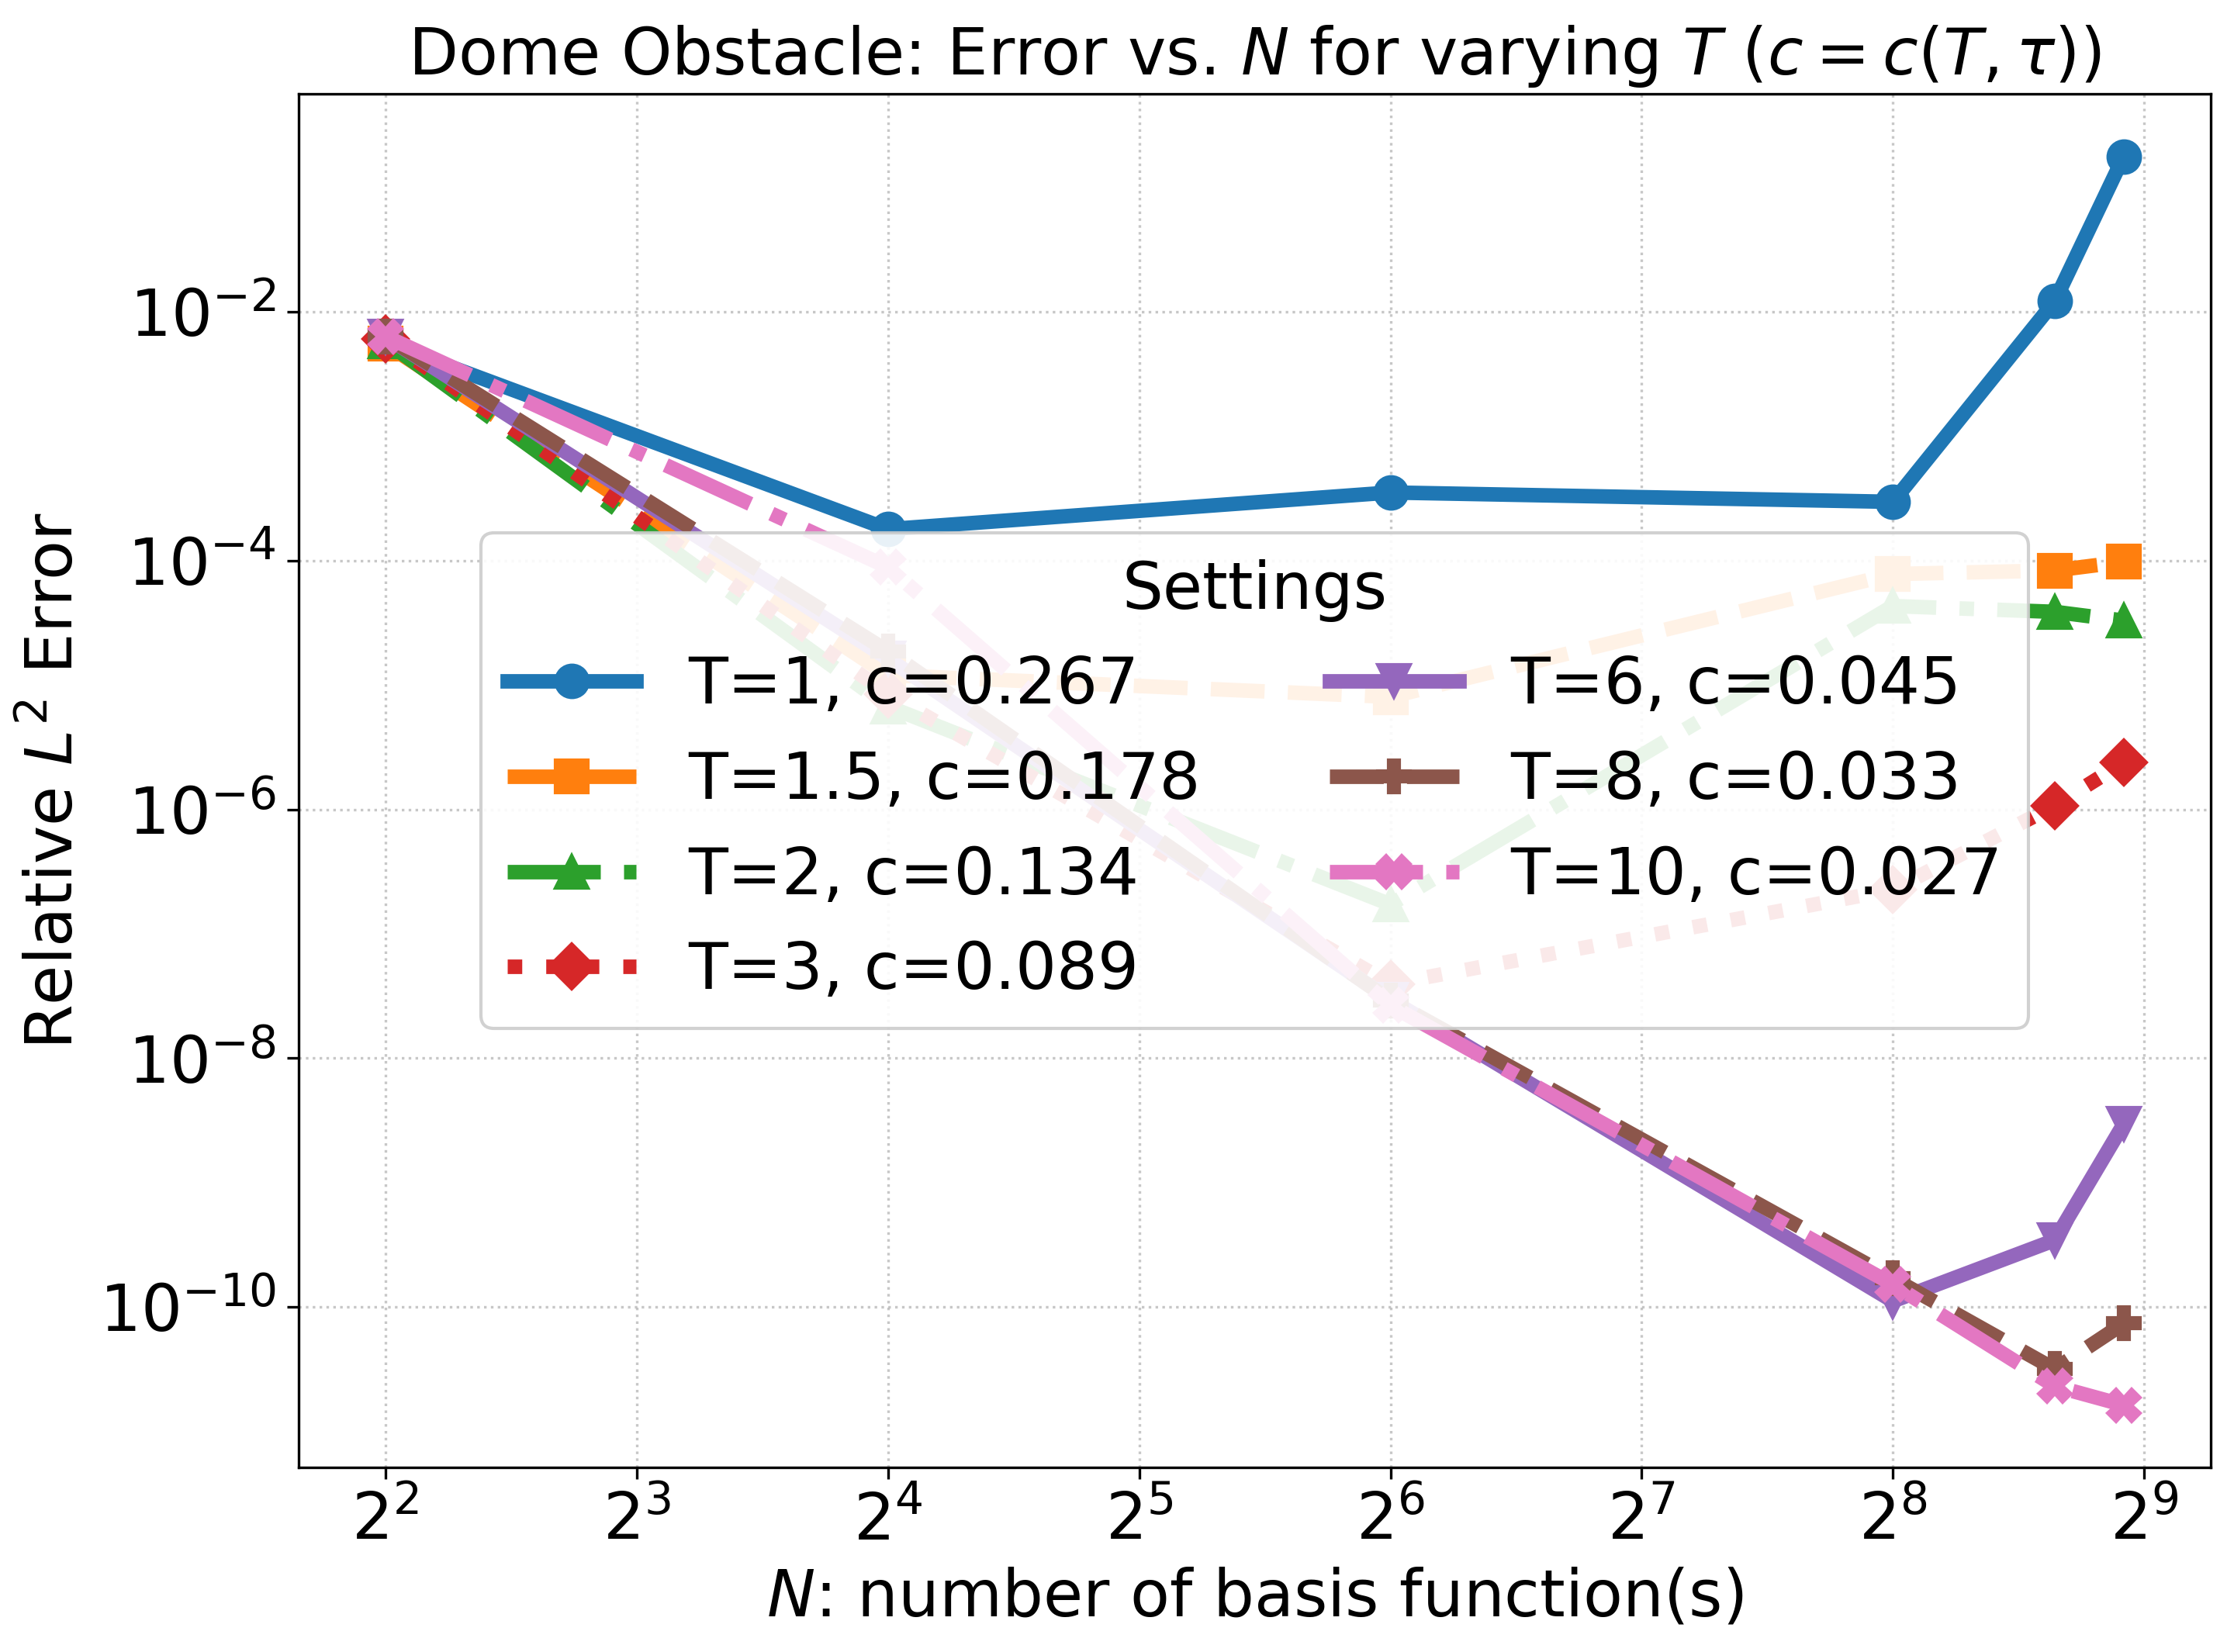

In [4]:
import os, time, csv
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle

# =======================
# Plot style
# =======================
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "legend.fontsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "lines.linewidth": 4.5,
    "lines.markersize": 20,
    "grid.alpha": 0.7,
    "figure.dpi": 300
})

# =======================
# Config
# =======================
# Grid sizes per axis to test
N_side_vals = np.array([2,4,8,16,20,22], dtype=int)
N_vals      = N_side_vals ** 2

# Shape parameter sweep via T (used to compute c)
T_values = np.array([1.0, 1.5, 2.0, 3.0, 6.0, 8.0, 10.0], dtype=float)

def c_from_T_tau(T: float, tau: float) -> float:
    # same formula you used
    return float(np.pi / (T * np.sqrt(2.0 * np.log(1.0 + tau**(-2)))))

tau_used = 1e-15
c_map = {float(T): c_from_T_tau(float(T), tau_used) for T in T_values}

# Output dirs/files
base_dir   = "./Outputs/2D_Obstacle/Psi_Cont"
os.makedirs(base_dir, exist_ok=True)
png_path   = os.path.join(base_dir, "fig4_obstacle_2D.png")
#csv_path   = os.path.join(base_dir, "results_solver_obstacle_2D.csv")

legend_ncols = 2

# =======================
# Run experiments
# =======================
E = {}        # T -> relL2 array vs N_side
Times = {}    # T -> wall time array vs N_side
C_used = {}   # T -> c used per N_side (to reflect your N_side>19 rule)

print("Running rbf_obstacle_solver grid ...")
rows = [("T", "N_side", "N", "c_used", "relL2", "time_sec")]  # for CSV

for T in T_values:
    errs, times, c_used_list = [], [], []
    c_T = c_map[float(T)]
    print(f"\nT = {T:g} (baseline c = {c_T:.3f})")

    for N_side in N_side_vals:
        N = int(N_side) ** 2
        zeta_used = 2.0
        # Mirror your rule: halve c when N_side > 19
        #c_used = c_T if (N_side < 19) else 0.5 * c_T
        c_used = c_T
        M_plot = int(zeta_used * N)
        t0 = time.perf_counter()
        res = rbf_obstacle_solver(
            N=N,
            T_kernel=float(T),
            c_val=float(c_T),
            beta_bc=1e6,
            tau_val=tau_used,
            zeta=zeta_used,
            sampling_choice="random",
            seed=123456,
            M_plot = M_plot  # for error calc
        )
        dt = time.perf_counter() - t0

        rel_err = float(res["rel_L2_error"])
        errs.append(rel_err)
        times.append(dt)
        c_used_list.append(c_used)

        print(f"  N ={N:4d}  relL2={rel_err:.3e}  time={dt:.3f}s  (c_used={c_used:.3f})")
        rows.append((f"{T:g}", f"{N_side:d}", f"{N:d}", f"{c_used:.3f}", f"{rel_err:.6e}", f"{dt:.6f}"))

    E[float(T)]      = np.asarray(errs, dtype=float)
    Times[float(T)]  = np.asarray(times, dtype=float)
    C_used[float(T)] = np.asarray(c_used_list, dtype=float)

# =======================
# Save CSV
# =======================
#with open(csv_path, "w", newline="") as f:
#    writer = csv.writer(f)
#    writer.writerows(rows)
#print(f"\nSaved results CSV to: {csv_path}")

# =======================
# Plot Error vs N (log-log)
# =======================
marker_cycle    = cycle(['o', 's', '^', 'D', 'v', 'P', 'X', '*'])
linestyle_cycle = cycle(['-', '--', '-.', ':'])

fig, ax = plt.subplots(figsize=(10, 7.5))
for T in T_values:
    y = np.asarray(E[float(T)], dtype=float)
    # show the baseline c(T, tau) (legend label), even if we halved c for large N_side
    c_val_label = c_map[float(T)]
    ax.plot(
        N_vals, y,
        marker=next(marker_cycle),
        linestyle=next(linestyle_cycle),
        markersize=10,
        label=f"T={T:g}, c={c_val_label:.3f}"
    )

ax.set_xscale('log', base=2)
ax.set_yscale('log')
ax.set_xlabel(r"$N$: number of basis function(s)")
ax.set_ylabel(r"Relative $L^2$ Error")
ax.set_title(r"Dome Obstacle: Error vs. $N$ for varying $T$ ($c=c(T,\tau)$)")
ax.grid(True, which='both', linestyle=':')

leg = ax.legend(title="Settings", ncol=legend_ncols, frameon=True, loc='center')
leg.get_frame().set_alpha(0.9)

fig.tight_layout()
fig.savefig(png_path)
# plt.show()

print(f"\nSaved plot to: {png_path}")

# ========== quick best summary ==========
for T in T_values:
    y = np.asarray(E[float(T)], dtype=float)
    j_best = np.nanargmin(y)
    best_val = y[j_best]
    print(f"T={T:g}: best relL2={best_val:.3e} at N_side={N_side_vals[j_best]} (N={N_side_vals[j_best]**2})")

print("\nLegend baseline c(T,τ) values (tau =", tau_used, "):")
for T in T_values:
    print(f"  T={T:>4g}  c={c_map[float(T)]:.3f}")


# Benchmark for different values of $c$

Running rbf_obstacle_solver grid (T fixed; sweep c) ...

T (fixed) = 3, tau = 1e-15, c_optim = 0.089093

>>> c = 0.026700


/tmp/ipykernel_996383/1427297051.py:316: RuntimeWarning: invalid value encountered in scalar divide
  imp_prim = (best_prim - primal_res) / (best_prim if best_prim > tiny else tiny)
/tmp/ipykernel_996383/1427297051.py:317: RuntimeWarning: invalid value encountered in scalar divide
  imp_dual = (best_dual - dual_res)   / (best_dual if best_dual > tiny else tiny)


  N =   4  relL2=6.325e-03  time=2.521s
  N =  16  relL2=8.835e-05  time=2.683s
  N =  64  relL2=2.658e-08  time=0.049s
  N = 256  relL2=1.517e-10  time=1.865s
  N = 400  relL2=2.314e-11  time=6.106s
  N = 484  relL2=1.624e-11  time=10.665s

>>> c = 0.030000
  N =   4  relL2=6.318e-03  time=2.596s
  N =  16  relL2=1.886e-05  time=2.684s
  N =  64  relL2=2.759e-08  time=0.049s
  N = 256  relL2=1.656e-10  time=1.802s
  N = 400  relL2=2.487e-11  time=6.064s
  N = 484  relL2=3.062e-11  time=10.473s

>>> c = 0.089093
  N =   4  relL2=6.053e-03  time=2.510s
  N =  16  relL2=8.448e-06  time=2.621s
  N =  64  relL2=3.953e-08  time=0.072s
  N = 256  relL2=2.259e-07  time=24.861s
  N = 400  relL2=1.072e-06  time=99.588s
  N = 484  relL2=2.386e-06  time=130.894s

>>> c = 0.080000
  N =   4  relL2=6.107e-03  time=2.512s
  N =  16  relL2=9.585e-06  time=2.625s
  N =  64  relL2=3.582e-08  time=0.053s
  N = 256  relL2=4.229e-08  time=19.001s
  N = 400  relL2=3.263e-07  time=102.026s
  N = 484  relL2=

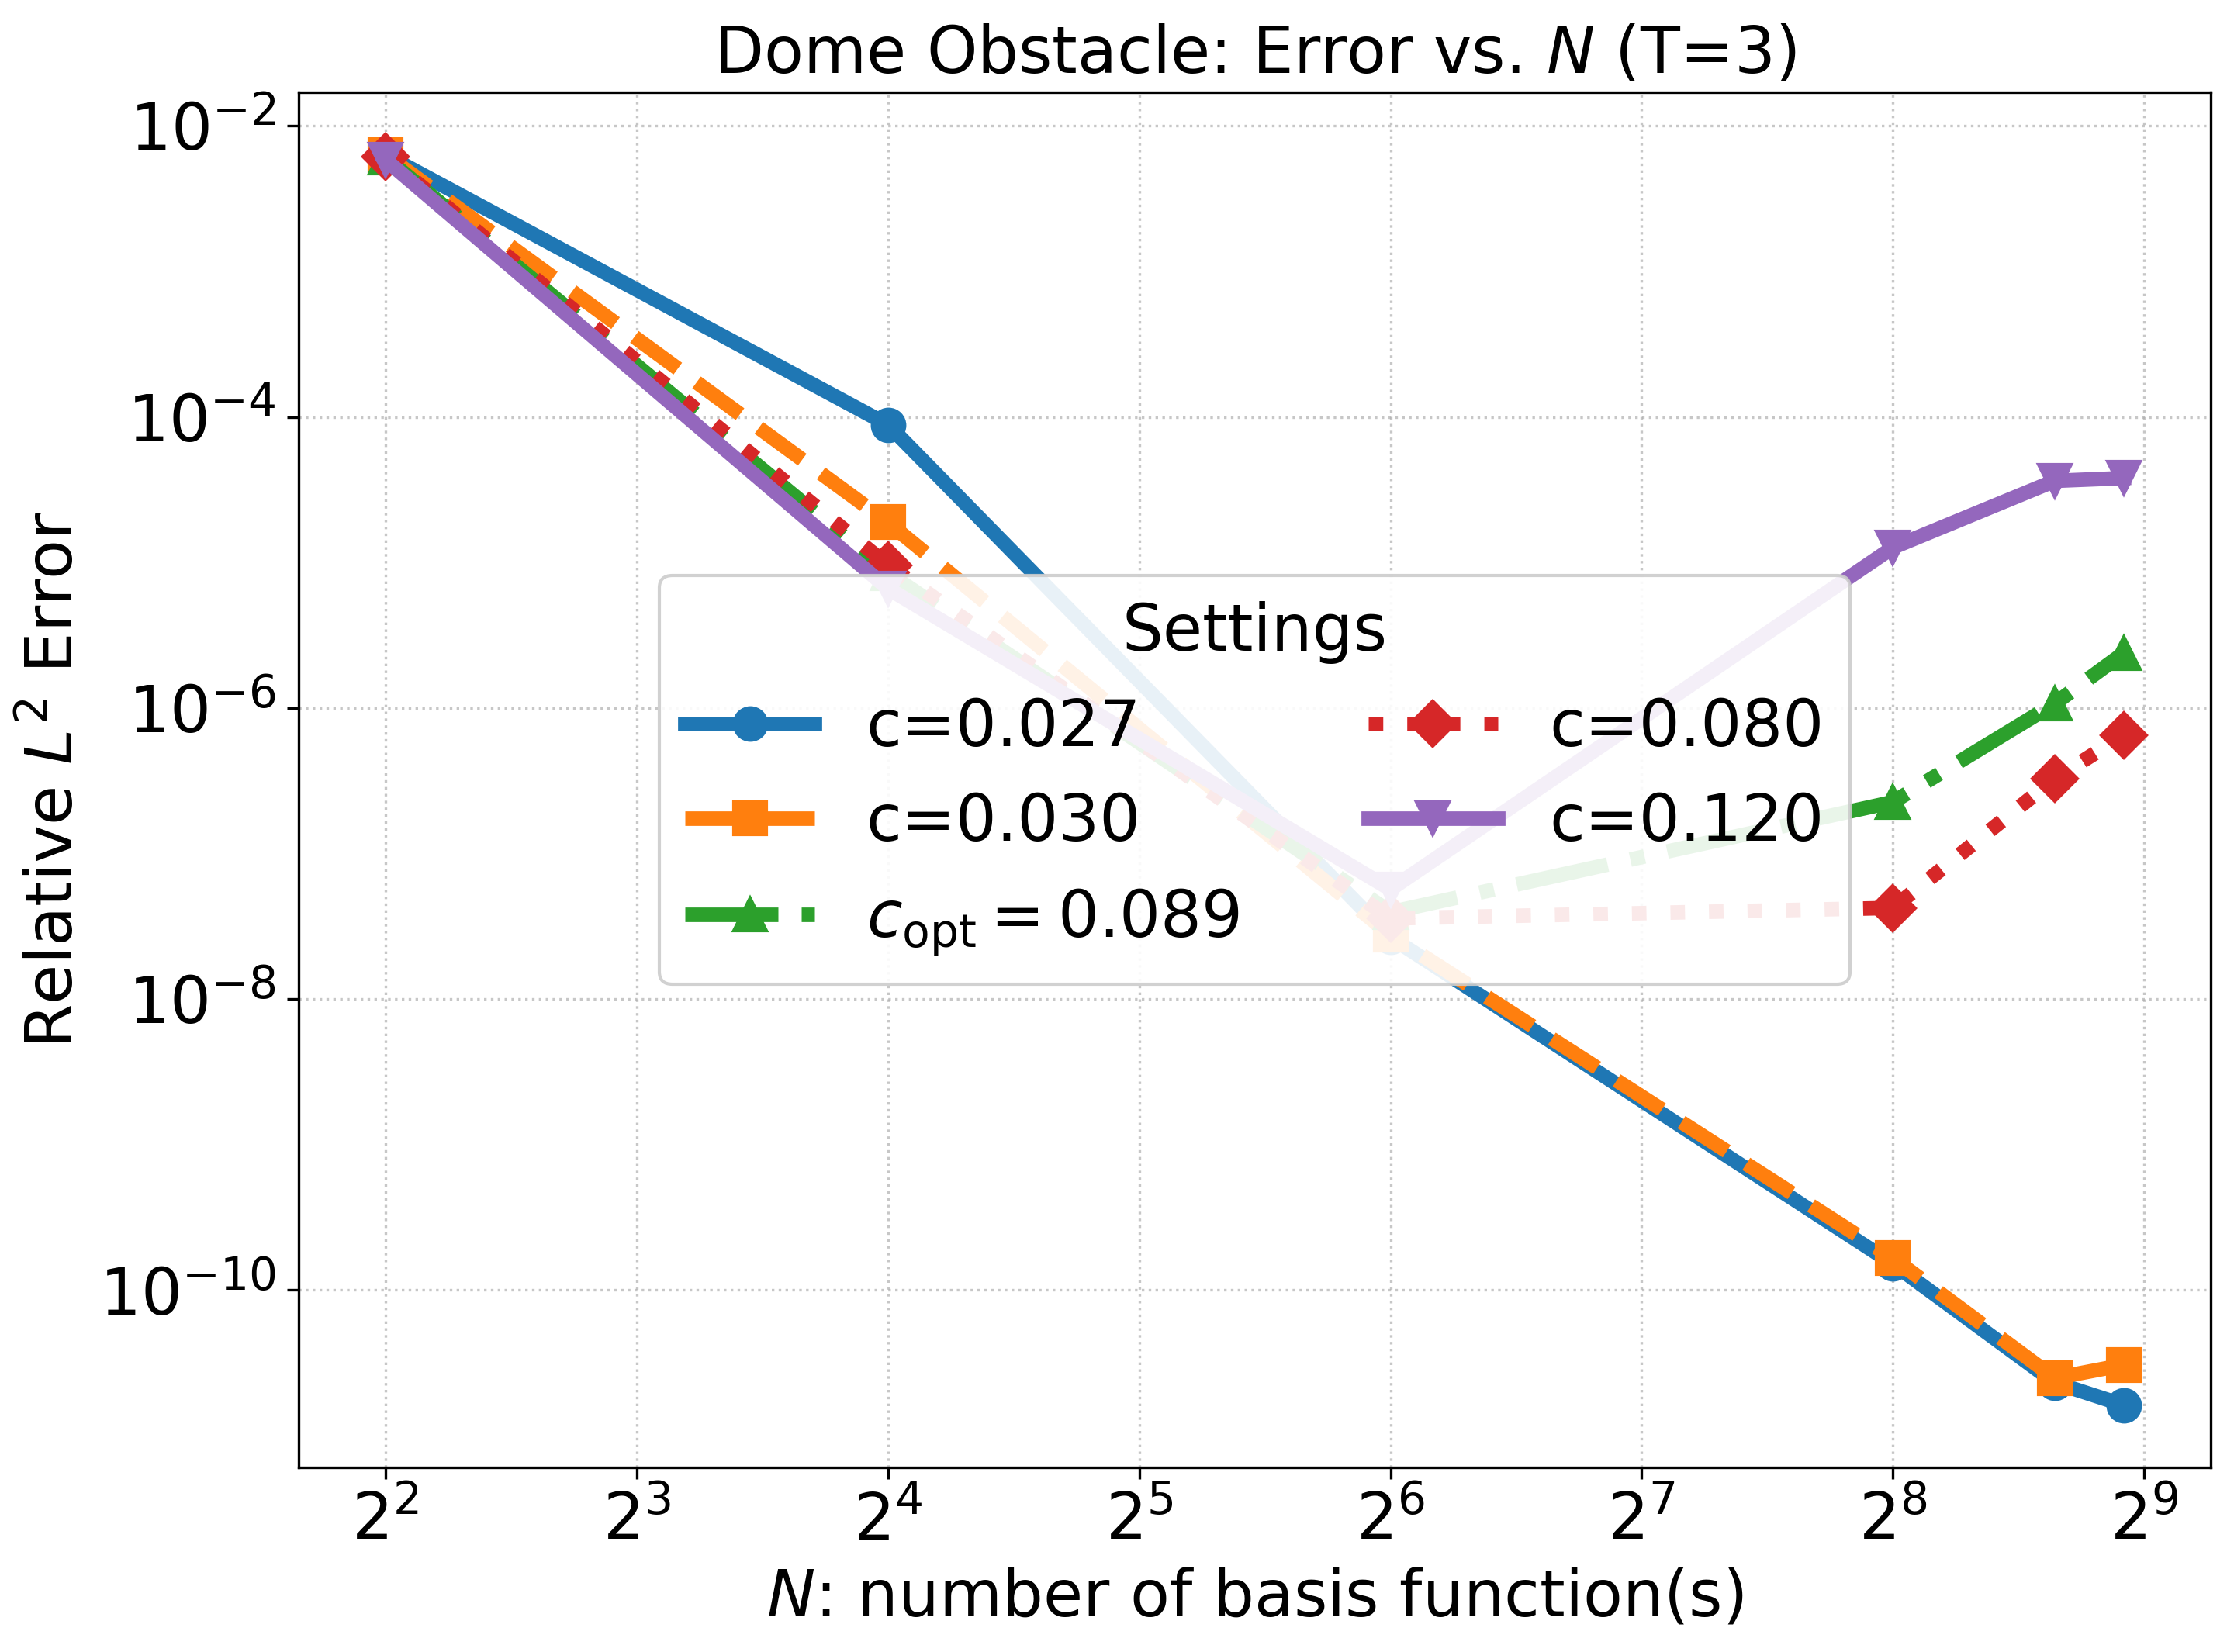

In [5]:
import os, time, csv
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle

# =======================
# Plot style
# =======================
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "legend.fontsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "lines.linewidth": 4.5,
    "lines.markersize": 20,
    "grid.alpha": 0.7,
    "figure.dpi": 300
})

# =======================
# Config (fixed T; sweep c)
# =======================
N_side_vals = np.array([2, 4, 8, 16, 20, 22], dtype=int)
N_vals      = N_side_vals ** 2

T_fixed   = 3.0
tau_used  = 1e-15

def c_from_T_tau(T: float, tau: float) -> float:
    return float(np.pi / (T * np.sqrt(2.0 * np.log(1.0 + tau**(-2)))))

c_optim  = c_from_T_tau(T_fixed, tau_used)
c_values = np.array([0.0267, 0.03, c_optim, 0.08, 0.12], dtype=float)

# Output dirs/files
base_dir = "./Outputs/2D_Obstacle/Psi_Cont"
os.makedirs(base_dir, exist_ok=True)
png_path = os.path.join(base_dir, "fig5_obstacle_2D.png")

legend_ncols = 2

# =======================
# Run experiments (sweep c)
# =======================
E = {}        # c -> relL2 array vs N_side
Times = {}    # c -> wall time array vs N_side

print("Running rbf_obstacle_solver grid (T fixed; sweep c) ...")
rows = [("T", "N_side", "N", "c_used", "relL2", "time_sec")]

print(f"\nT (fixed) = {T_fixed:g}, tau = {tau_used:g}, c_optim = {c_optim:.6f}")

for c_used in c_values:
    errs, times = [], []
    print(f"\n>>> c = {c_used:.6f}")

    for N_side in N_side_vals:
        N = int(N_side) ** 2
        zeta_used = 2.0
        M_plot = int(zeta_used * N)

        t0 = time.perf_counter()
        res = rbf_obstacle_solver(
            N=N,
            T_kernel=float(T_fixed),
            c_val=float(c_used),     # <-- sweep c here
            beta_bc=1e6,
            tau_val=tau_used,
            zeta=zeta_used,
            sampling_choice="random",
            seed=123456,
            M_plot=M_plot
        )
        dt = time.perf_counter() - t0

        rel_err = float(res["rel_L2_error"])
        errs.append(rel_err)
        times.append(dt)

        print(f"  N ={N:4d}  relL2={rel_err:.3e}  time={dt:.3f}s")
        rows.append((f"{T_fixed:g}", f"{N_side:d}", f"{N:d}", f"{c_used:.6f}", f"{rel_err:.6e}", f"{dt:.6f}"))

    E[float(c_used)]     = np.asarray(errs, dtype=float)
    Times[float(c_used)] = np.asarray(times, dtype=float)

# =======================
# Plot Error vs N (log-log)
# =======================
marker_cycle    = cycle(['o', 's', '^', 'D', 'v', 'P', 'X', '*'])
linestyle_cycle = cycle(['-', '--', '-.', ':'])

fig, ax = plt.subplots(figsize=(10, 7.5))
for c_used in c_values:
    y = np.asarray(E[float(c_used)], dtype=float)
    label = (f"c={c_used:.3f}" if not np.isclose(c_used, c_optim)
             else rf"$c_\mathrm{{opt}}={c_used:.3f}$")
    ax.plot(
        N_vals, y,
        marker=next(marker_cycle),
        linestyle=next(linestyle_cycle),
        markersize=10,
        label=label
    )

ax.set_xscale('log', base=2)
ax.set_yscale('log')
ax.set_xlabel(r"$N$: number of basis function(s)")
ax.set_ylabel(r"Relative $L^2$ Error")
ax.set_title(rf"Dome Obstacle: Error vs. $N$ (T={T_fixed:g})")
ax.grid(True, which='both', linestyle=':')

leg = ax.legend(title="Settings", ncol=legend_ncols, frameon=True, loc='center')
leg.get_frame().set_alpha(0.9)

fig.tight_layout()
fig.savefig(png_path)
# plt.show()

print(f"\nSaved plot to: {png_path}")

# ========== quick best summary ==========
for c_used in c_values:
    y = np.asarray(E[float(c_used)], dtype=float)
    j_best = np.nanargmin(y)
    best_val = y[j_best]
    print(f"c={c_used:.6f}: best relL2={best_val:.3e} at N_side={N_side_vals[j_best]} (N={N_side_vals[j_best]**2})")

print("\nLegend values:")
print(f"  T_fixed={T_fixed:g}, tau={tau_used:g}, c_optim={c_optim:.6f}")


# T = 6.0

Running rbf_obstacle_solver grid (T fixed; sweep c) ...

T (fixed) = 6, tau = 1e-15, c_optim = 0.044547

>>> c = 0.026700


/tmp/ipykernel_996383/1427297051.py:316: RuntimeWarning: invalid value encountered in scalar divide
  imp_prim = (best_prim - primal_res) / (best_prim if best_prim > tiny else tiny)
/tmp/ipykernel_996383/1427297051.py:317: RuntimeWarning: invalid value encountered in scalar divide
  imp_dual = (best_dual - dual_res)   / (best_dual if best_dual > tiny else tiny)


  N =   4  relL2=6.325e-03  time=2.528s
  N =  16  relL2=8.835e-05  time=2.711s
  N =  64  relL2=2.658e-08  time=0.046s
  N = 256  relL2=1.517e-10  time=1.834s
  N = 400  relL2=2.314e-11  time=6.078s
  N = 484  relL2=1.624e-11  time=10.913s

>>> c = 0.030000
  N =   4  relL2=6.318e-03  time=2.541s
  N =  16  relL2=1.886e-05  time=2.646s
  N =  64  relL2=2.759e-08  time=0.048s
  N = 256  relL2=1.656e-10  time=1.770s
  N = 400  relL2=2.487e-11  time=6.018s
  N = 484  relL2=3.062e-11  time=10.938s

>>> c = 0.044547
  N =   4  relL2=6.274e-03  time=2.545s
  N =  16  relL2=1.625e-05  time=2.687s
  N =  64  relL2=2.944e-08  time=0.058s
  N = 256  relL2=1.116e-10  time=1.663s
  N = 400  relL2=3.451e-10  time=6.426s
  N = 484  relL2=2.972e-09  time=17.043s

>>> c = 0.080000
  N =   4  relL2=6.107e-03  time=2.525s
  N =  16  relL2=9.585e-06  time=2.691s
  N =  64  relL2=3.582e-08  time=0.053s
  N = 256  relL2=4.229e-08  time=18.445s
  N = 400  relL2=3.263e-07  time=99.123s
  N = 484  relL2=6.52

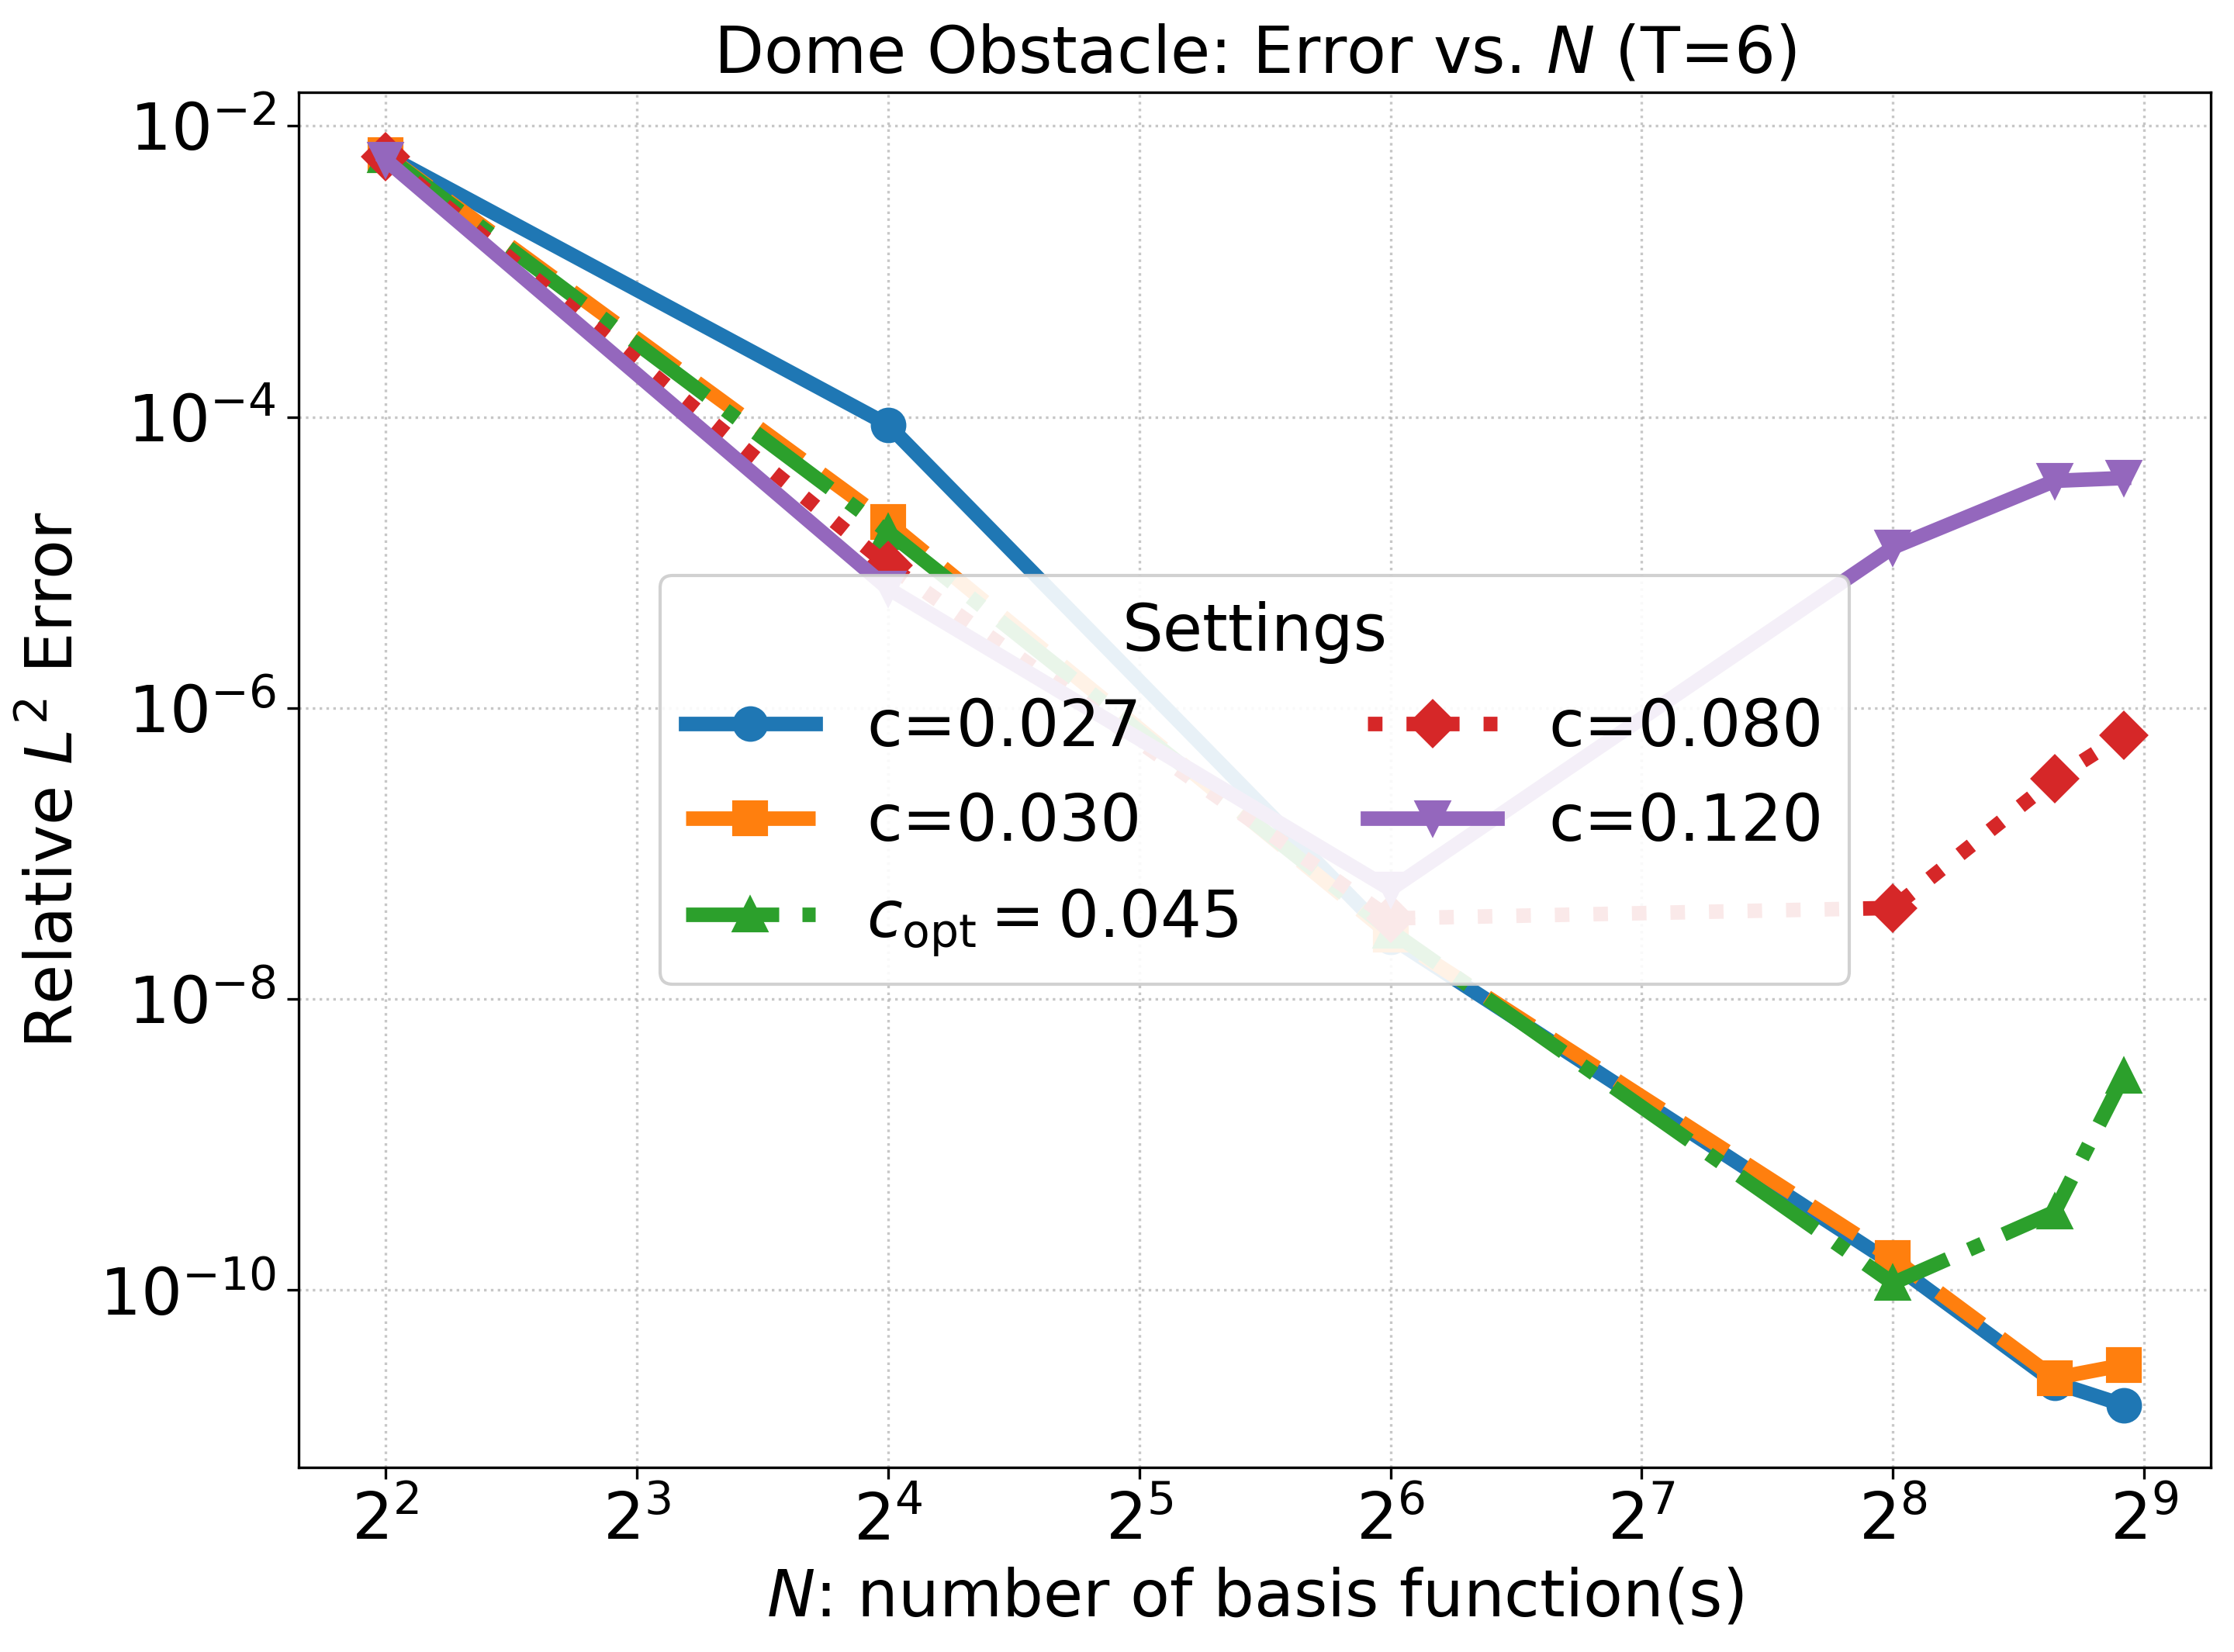

In [6]:
# =======================
# Config (fixed T; sweep c)
# =======================
N_side_vals = np.array([2, 4, 8, 16, 20, 22], dtype=int)
N_vals      = N_side_vals ** 2

T_fixed   = 6.0
tau_used  = 1e-15

def c_from_T_tau(T: float, tau: float) -> float:
    return float(np.pi / (T * np.sqrt(2.0 * np.log(1.0 + tau**(-2)))))

c_optim  = c_from_T_tau(T_fixed, tau_used)
c_values = np.array([0.0267, 0.03, c_optim, 0.08, 0.12], dtype=float)

# Output dirs/files
base_dir = "./Outputs/2D_Obstacle/Psi_Cont"
os.makedirs(base_dir, exist_ok=True)
png_path = os.path.join(base_dir, "fig6_obstacle_2D.png")

legend_ncols = 2

# =======================
# Run experiments (sweep c)
# =======================
E = {}        # c -> relL2 array vs N_side
Times = {}    # c -> wall time array vs N_side

print("Running rbf_obstacle_solver grid (T fixed; sweep c) ...")
rows = [("T", "N_side", "N", "c_used", "relL2", "time_sec")]

print(f"\nT (fixed) = {T_fixed:g}, tau = {tau_used:g}, c_optim = {c_optim:.6f}")

for c_used in c_values:
    errs, times = [], []
    print(f"\n>>> c = {c_used:.6f}")

    for N_side in N_side_vals:
        N = int(N_side) ** 2
        zeta_used = 2.0
        M_plot = int(zeta_used * N)

        t0 = time.perf_counter()
        res = rbf_obstacle_solver(
            N=N,
            T_kernel=float(T_fixed),
            c_val=float(c_used),     # <-- sweep c here
            beta_bc=1e6,
            tau_val=tau_used,
            zeta=zeta_used,
            sampling_choice="random",
            seed=123456,
            M_plot=M_plot
        )
        dt = time.perf_counter() - t0

        rel_err = float(res["rel_L2_error"])
        errs.append(rel_err)
        times.append(dt)

        print(f"  N ={N:4d}  relL2={rel_err:.3e}  time={dt:.3f}s")
        rows.append((f"{T_fixed:g}", f"{N_side:d}", f"{N:d}", f"{c_used:.6f}", f"{rel_err:.6e}", f"{dt:.6f}"))

    E[float(c_used)]     = np.asarray(errs, dtype=float)
    Times[float(c_used)] = np.asarray(times, dtype=float)

# =======================
# Plot Error vs N (log-log)
# =======================
marker_cycle    = cycle(['o', 's', '^', 'D', 'v', 'P', 'X', '*'])
linestyle_cycle = cycle(['-', '--', '-.', ':'])

fig, ax = plt.subplots(figsize=(10, 7.5))
for c_used in c_values:
    y = np.asarray(E[float(c_used)], dtype=float)
    label = (f"c={c_used:.3f}" if not np.isclose(c_used, c_optim)
             else rf"$c_\mathrm{{opt}}={c_used:.3f}$")
    ax.plot(
        N_vals, y,
        marker=next(marker_cycle),
        linestyle=next(linestyle_cycle),
        markersize=10,
        label=label
    )

ax.set_xscale('log', base=2)
ax.set_yscale('log')
ax.set_xlabel(r"$N$: number of basis function(s)")
ax.set_ylabel(r"Relative $L^2$ Error")
ax.set_title(rf"Dome Obstacle: Error vs. $N$ (T={T_fixed:g})")
ax.grid(True, which='both', linestyle=':')

leg = ax.legend(title="Settings", ncol=legend_ncols, frameon=True, loc='center')
leg.get_frame().set_alpha(0.9)

fig.tight_layout()
fig.savefig(png_path)
# plt.show()

print(f"\nSaved plot to: {png_path}")

# ========== quick best summary ==========
for c_used in c_values:
    y = np.asarray(E[float(c_used)], dtype=float)
    j_best = np.nanargmin(y)
    best_val = y[j_best]
    print(f"c={c_used:.6f}: best relL2={best_val:.3e} at N_side={N_side_vals[j_best]} (N={N_side_vals[j_best]**2})")

print("\nLegend values:")
print(f"  T_fixed={T_fixed:g}, tau={tau_used:g}, c_optim={c_optim:.6f}")


# T = 8.0

Running rbf_obstacle_solver grid (T fixed; sweep c) ...

T (fixed) = 8, tau = 1e-15, c_optim = 0.033410

>>> c = 0.026700


/tmp/ipykernel_996383/1427297051.py:316: RuntimeWarning: invalid value encountered in scalar divide
  imp_prim = (best_prim - primal_res) / (best_prim if best_prim > tiny else tiny)
/tmp/ipykernel_996383/1427297051.py:317: RuntimeWarning: invalid value encountered in scalar divide
  imp_dual = (best_dual - dual_res)   / (best_dual if best_dual > tiny else tiny)


  N =   4  relL2=6.325e-03  time=2.536s
  N =  16  relL2=8.835e-05  time=2.637s
  N =  64  relL2=2.658e-08  time=0.045s
  N = 256  relL2=1.517e-10  time=1.895s
  N = 400  relL2=2.314e-11  time=6.219s
  N = 484  relL2=1.624e-11  time=10.818s

>>> c = 0.033410
  N =   4  relL2=6.309e-03  time=2.577s
  N =  16  relL2=1.860e-05  time=2.618s
  N =  64  relL2=2.906e-08  time=0.053s
  N = 256  relL2=1.698e-10  time=1.757s
  N = 400  relL2=3.169e-11  time=6.215s
  N = 484  relL2=7.396e-11  time=10.885s

>>> c = 0.080000
  N =   4  relL2=6.107e-03  time=2.528s
  N =  16  relL2=9.585e-06  time=2.609s
  N =  64  relL2=3.582e-08  time=0.052s
  N = 256  relL2=4.229e-08  time=18.958s
  N = 400  relL2=3.263e-07  time=104.218s
  N = 484  relL2=6.527e-07  time=145.845s

>>> c = 0.120000
  N =   4  relL2=5.853e-03  time=2.525s
  N =  16  relL2=6.623e-06  time=2.667s
  N =  64  relL2=5.675e-08  time=3.598s
  N = 256  relL2=1.267e-05  time=45.277s
  N = 400  relL2=3.637e-05  time=87.732s
  N = 484  relL2=

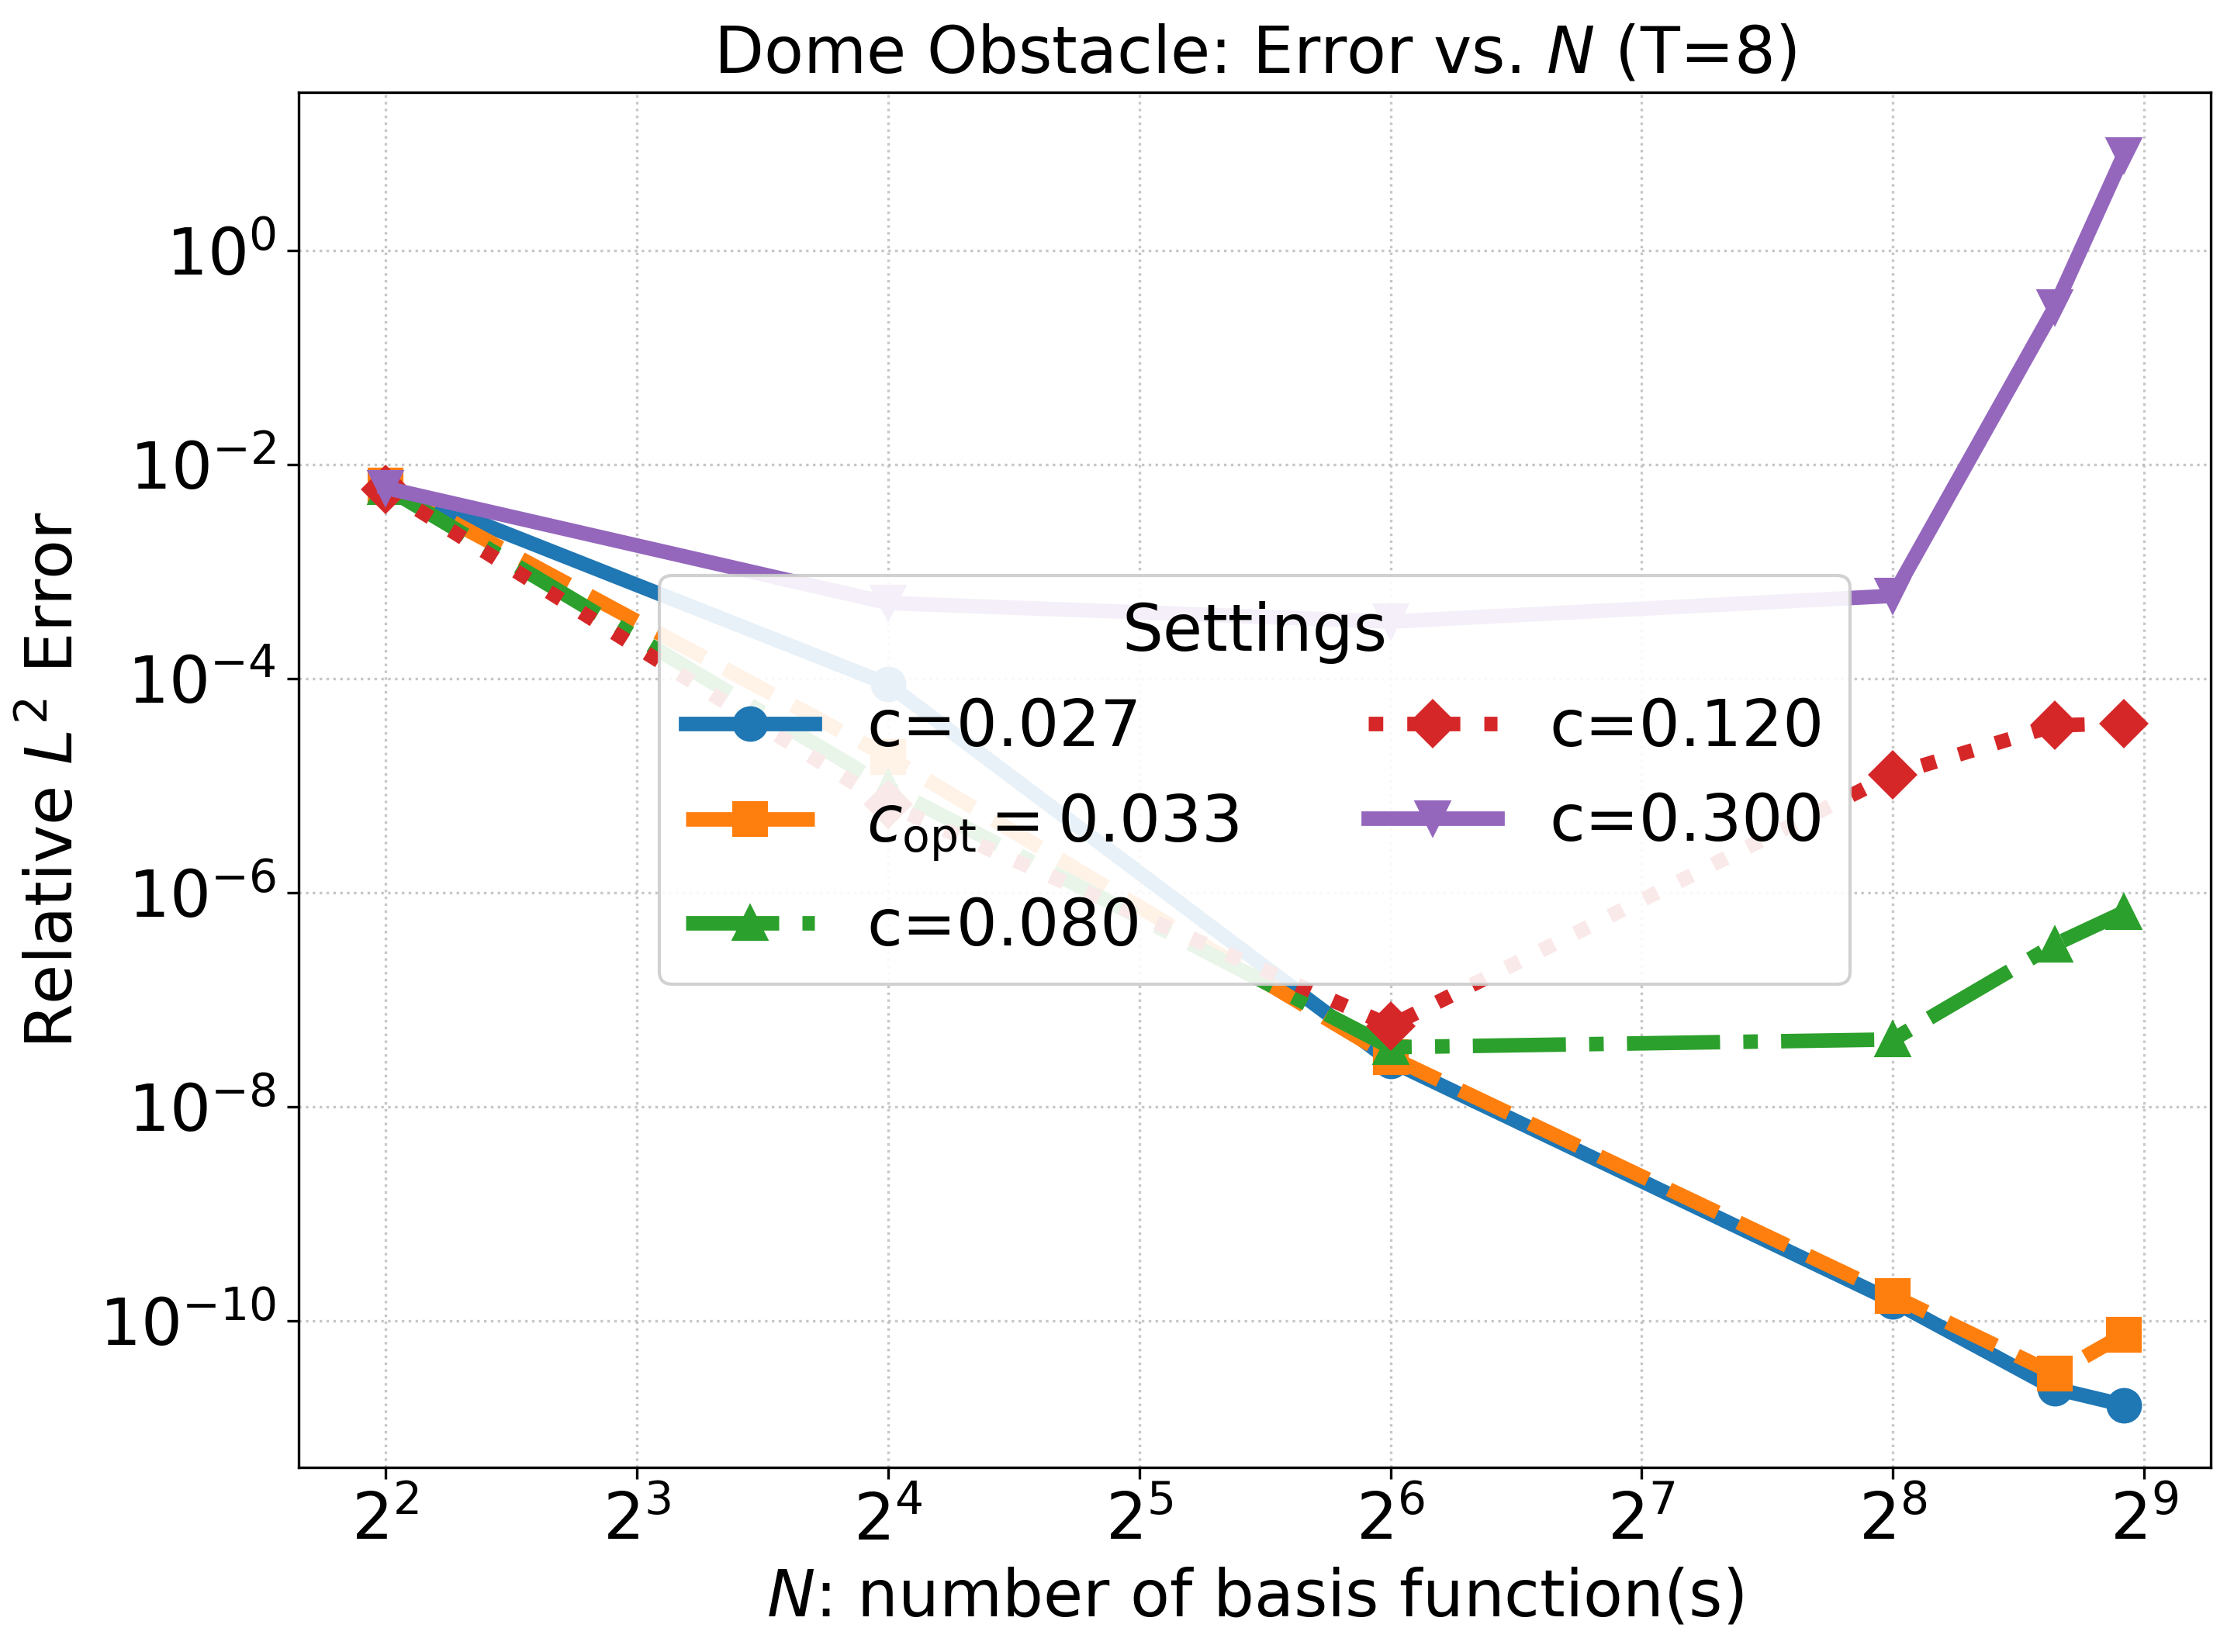

In [7]:
# =======================
# Config (fixed T; sweep c)
# =======================
N_side_vals = np.array([2, 4, 8, 16, 20, 22], dtype=int)
N_vals      = N_side_vals ** 2

T_fixed   = 8.0
tau_used  = 1e-15

def c_from_T_tau(T: float, tau: float) -> float:
    return float(np.pi / (T * np.sqrt(2.0 * np.log(1.0 + tau**(-2)))))

c_optim  = c_from_T_tau(T_fixed, tau_used)
c_values = np.array([0.0267, c_optim, 0.08, 0.12, 0.3], dtype=float)

# Output dirs/files
base_dir = "./Outputs/2D_Obstacle/Psi_Cont"
os.makedirs(base_dir, exist_ok=True)
png_path = os.path.join(base_dir, "fig7_obstacle_2D.png")

legend_ncols = 2

# =======================
# Run experiments (sweep c)
# =======================
E = {}        # c -> relL2 array vs N_side
Times = {}    # c -> wall time array vs N_side

print("Running rbf_obstacle_solver grid (T fixed; sweep c) ...")
rows = [("T", "N_side", "N", "c_used", "relL2", "time_sec")]

print(f"\nT (fixed) = {T_fixed:g}, tau = {tau_used:g}, c_optim = {c_optim:.6f}")

for c_used in c_values:
    errs, times = [], []
    print(f"\n>>> c = {c_used:.6f}")

    for N_side in N_side_vals:
        N = int(N_side) ** 2
        zeta_used = 2.0
        M_plot = int(zeta_used * N)

        t0 = time.perf_counter()
        res = rbf_obstacle_solver(
            N=N,
            T_kernel=float(T_fixed),
            c_val=float(c_used),     # <-- sweep c here
            beta_bc=1e6,
            tau_val=tau_used,
            zeta=zeta_used,
            sampling_choice="random",
            seed=123456,
            M_plot=M_plot
        )
        dt = time.perf_counter() - t0

        rel_err = float(res["rel_L2_error"])
        errs.append(rel_err)
        times.append(dt)

        print(f"  N ={N:4d}  relL2={rel_err:.3e}  time={dt:.3f}s")
        rows.append((f"{T_fixed:g}", f"{N_side:d}", f"{N:d}", f"{c_used:.6f}", f"{rel_err:.6e}", f"{dt:.6f}"))

    E[float(c_used)]     = np.asarray(errs, dtype=float)
    Times[float(c_used)] = np.asarray(times, dtype=float)

# =======================
# Plot Error vs N (log-log)
# =======================
marker_cycle    = cycle(['o', 's', '^', 'D', 'v', 'P', 'X', '*'])
linestyle_cycle = cycle(['-', '--', '-.', ':'])

fig, ax = plt.subplots(figsize=(10, 7.5))
for c_used in c_values:
    y = np.asarray(E[float(c_used)], dtype=float)
    label = (f"c={c_used:.3f}" if not np.isclose(c_used, c_optim)
             else rf"$c_\mathrm{{opt}}={c_used:.3f}$")
    ax.plot(
        N_vals, y,
        marker=next(marker_cycle),
        linestyle=next(linestyle_cycle),
        markersize=10,
        label=label
    )

ax.set_xscale('log', base=2)
ax.set_yscale('log')
ax.set_xlabel(r"$N$: number of basis function(s)")
ax.set_ylabel(r"Relative $L^2$ Error")
ax.set_title(rf"Dome Obstacle: Error vs. $N$ (T={T_fixed:g})")
ax.grid(True, which='both', linestyle=':')

leg = ax.legend(title="Settings", ncol=legend_ncols, frameon=True, loc='center')
leg.get_frame().set_alpha(0.9)

fig.tight_layout()
fig.savefig(png_path)
# plt.show()

print(f"\nSaved plot to: {png_path}")

# ========== quick best summary ==========
for c_used in c_values:
    y = np.asarray(E[float(c_used)], dtype=float)
    j_best = np.nanargmin(y)
    best_val = y[j_best]
    print(f"c={c_used:.6f}: best relL2={best_val:.3e} at N_side={N_side_vals[j_best]} (N={N_side_vals[j_best]**2})")

print("\nLegend values:")
print(f"  T_fixed={T_fixed:g}, tau={tau_used:g}, c_optim={c_optim:.6f}")


# T = 10.0

Running rbf_obstacle_solver grid (T fixed; sweep c) ...

T (fixed) = 10, tau = 1e-15, c_optim = 0.026728

>>> c = 0.030000


/tmp/ipykernel_996383/1427297051.py:316: RuntimeWarning: invalid value encountered in scalar divide
  imp_prim = (best_prim - primal_res) / (best_prim if best_prim > tiny else tiny)
/tmp/ipykernel_996383/1427297051.py:317: RuntimeWarning: invalid value encountered in scalar divide
  imp_dual = (best_dual - dual_res)   / (best_dual if best_dual > tiny else tiny)


  N =   4  relL2=6.318e-03  time=2.587s
  N =  16  relL2=1.886e-05  time=2.644s
  N =  64  relL2=2.759e-08  time=0.049s
  N = 256  relL2=1.656e-10  time=1.784s
  N = 400  relL2=2.487e-11  time=6.007s
  N = 484  relL2=3.062e-11  time=10.647s

>>> c = 0.026728
  N =   4  relL2=6.325e-03  time=2.571s
  N =  16  relL2=8.834e-05  time=2.677s
  N =  64  relL2=2.651e-08  time=0.046s
  N = 256  relL2=1.518e-10  time=1.950s
  N = 400  relL2=2.315e-11  time=6.048s
  N = 484  relL2=1.630e-11  time=10.769s

>>> c = 0.080000
  N =   4  relL2=6.107e-03  time=2.570s
  N =  16  relL2=9.585e-06  time=2.627s
  N =  64  relL2=3.582e-08  time=0.055s
  N = 256  relL2=4.229e-08  time=18.666s
  N = 400  relL2=3.263e-07  time=98.681s
  N = 484  relL2=6.527e-07  time=141.966s

>>> c = 0.120000
  N =   4  relL2=5.853e-03  time=2.469s
  N =  16  relL2=6.623e-06  time=2.564s
  N =  64  relL2=5.675e-08  time=3.511s
  N = 256  relL2=1.267e-05  time=43.532s
  N = 400  relL2=3.637e-05  time=81.538s
  N = 484  relL2=3

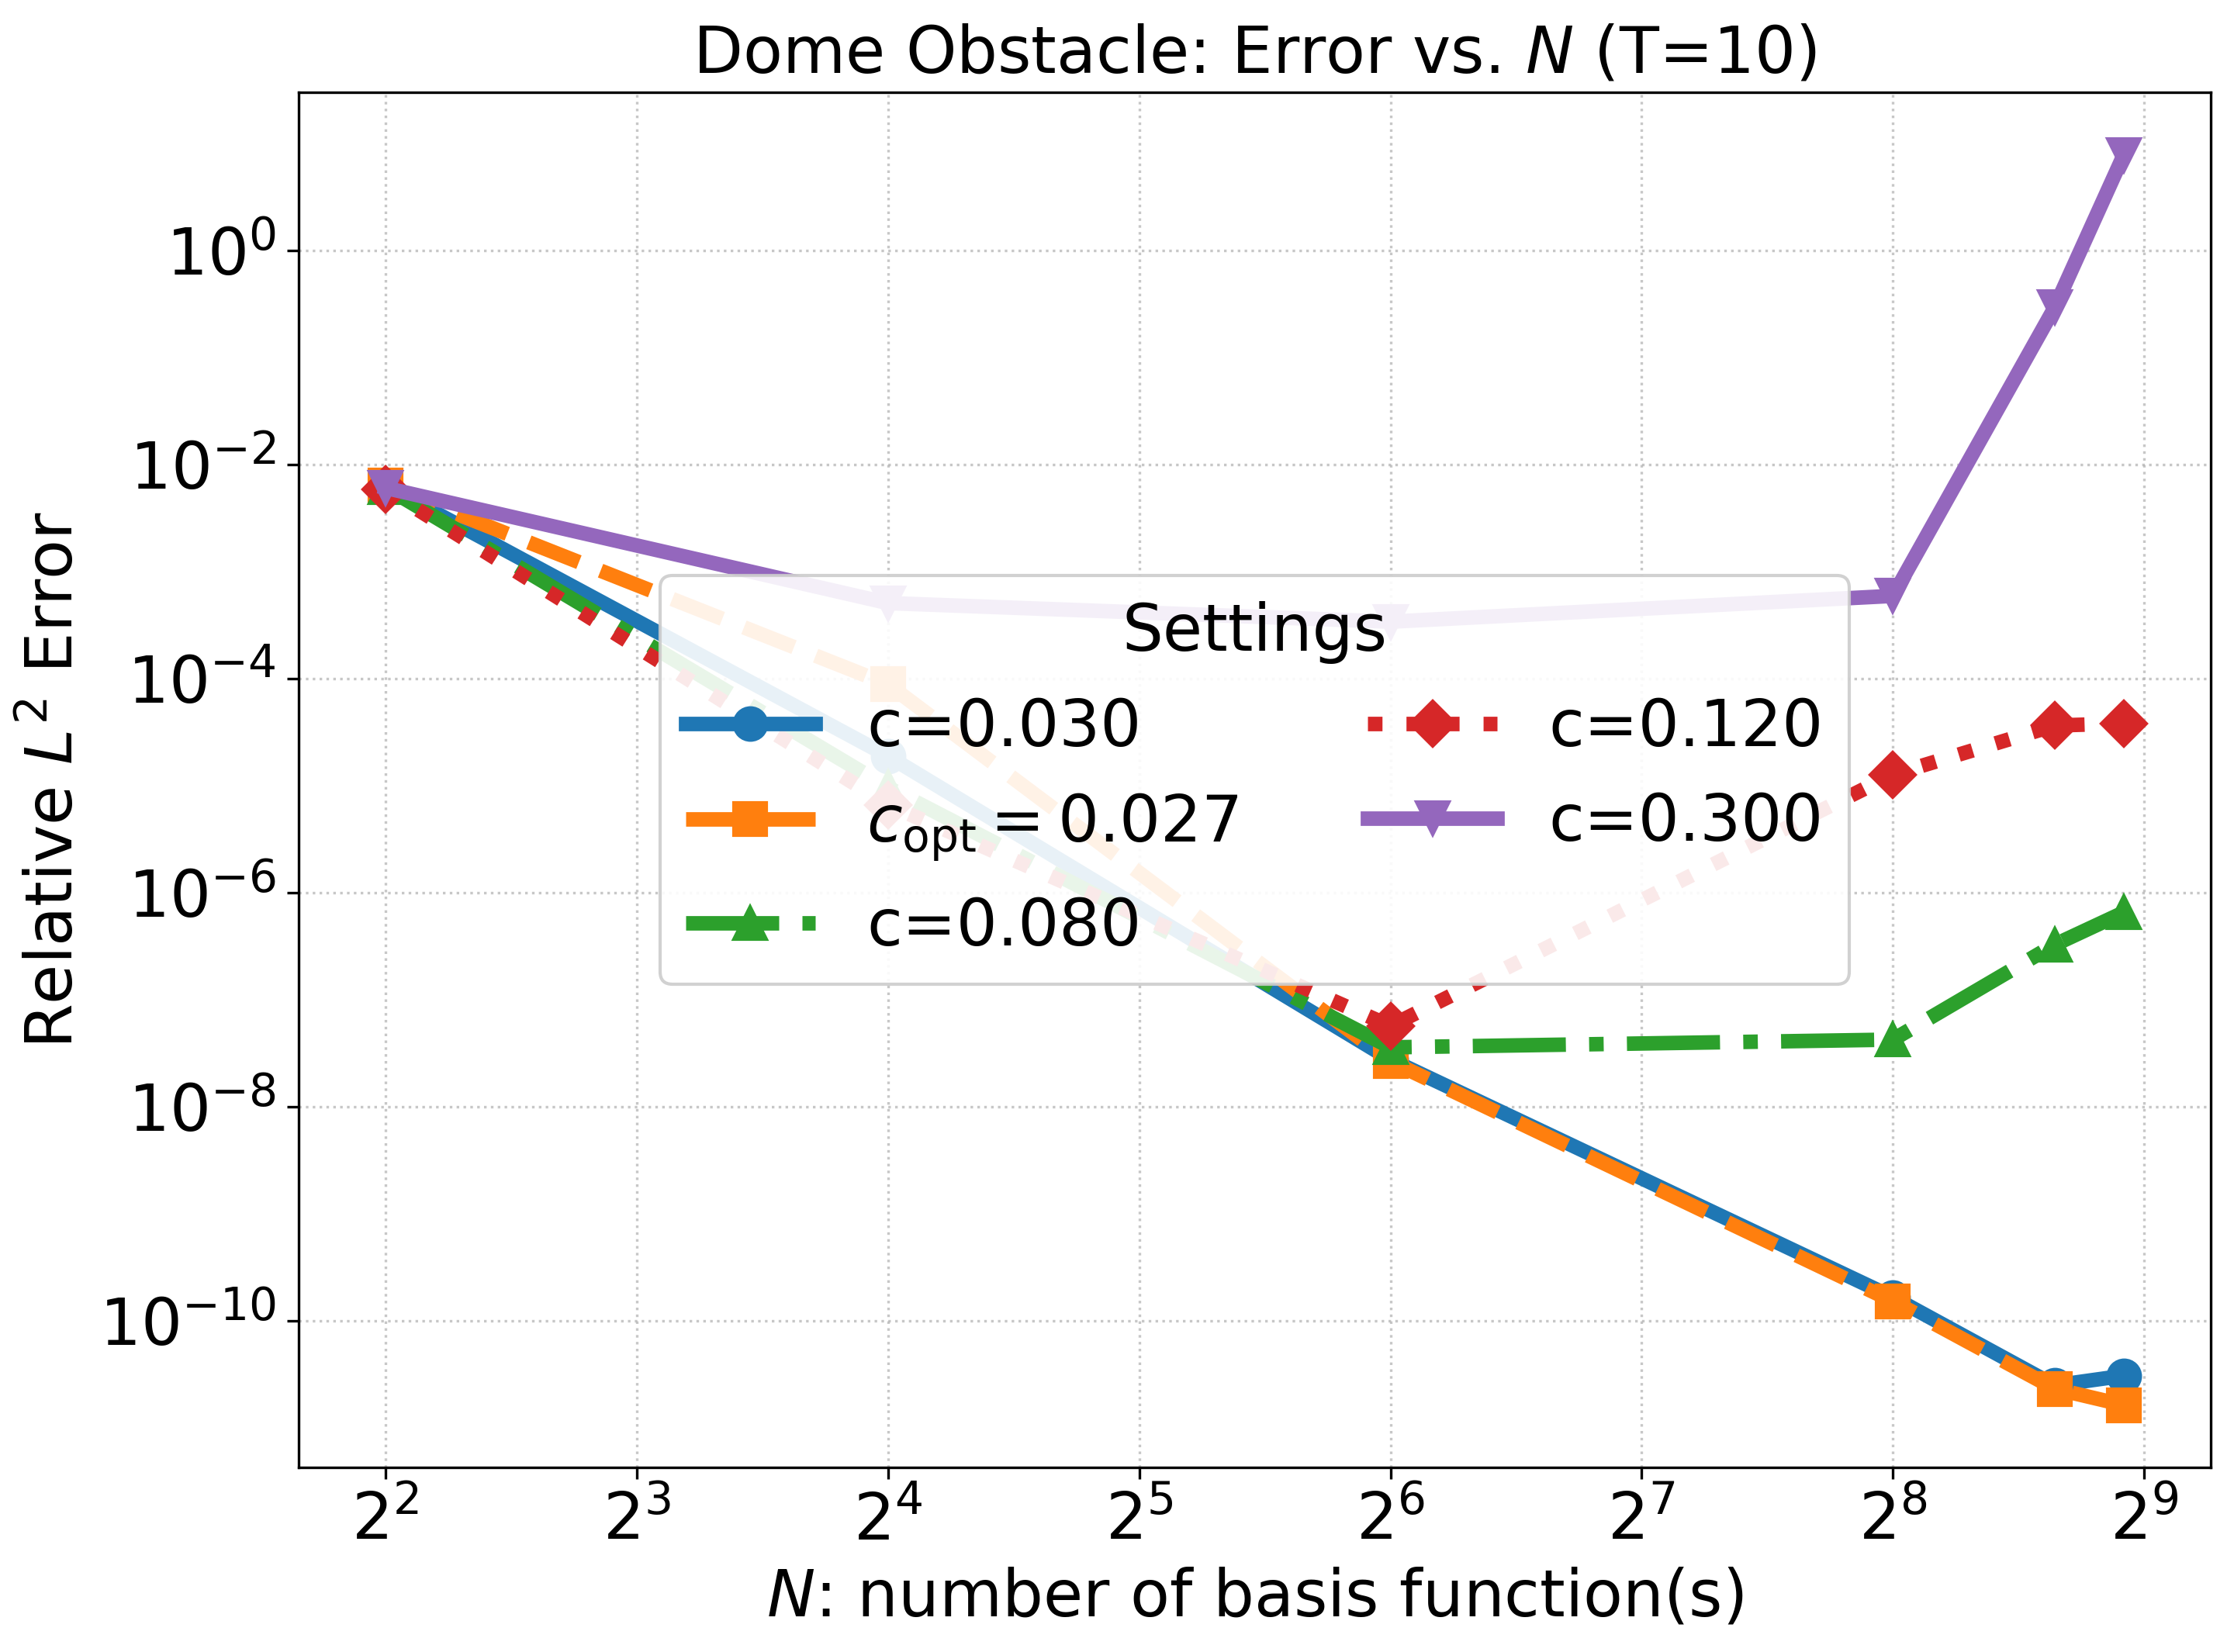

In [8]:
# =======================
# Config (fixed T; sweep c)
# =======================
N_side_vals = np.array([2, 4, 8, 16, 20, 22], dtype=int)
N_vals      = N_side_vals ** 2

T_fixed   = 10.0
tau_used  = 1e-15

def c_from_T_tau(T: float, tau: float) -> float:
    return float(np.pi / (T * np.sqrt(2.0 * np.log(1.0 + tau**(-2)))))

c_optim  = c_from_T_tau(T_fixed, tau_used)
c_values = np.array([0.03, c_optim, 0.08, 0.12, 0.3], dtype=float)

# Output dirs/files
base_dir = "./Outputs/2D_Obstacle/Psi_Cont"
os.makedirs(base_dir, exist_ok=True)
png_path = os.path.join(base_dir, "fig8_obstacle_2D.png")

legend_ncols = 2

# =======================
# Run experiments (sweep c)
# =======================
E = {}        # c -> relL2 array vs N_side
Times = {}    # c -> wall time array vs N_side

print("Running rbf_obstacle_solver grid (T fixed; sweep c) ...")
rows = [("T", "N_side", "N", "c_used", "relL2", "time_sec")]

print(f"\nT (fixed) = {T_fixed:g}, tau = {tau_used:g}, c_optim = {c_optim:.6f}")

for c_used in c_values:
    errs, times = [], []
    print(f"\n>>> c = {c_used:.6f}")

    for N_side in N_side_vals:
        N = int(N_side) ** 2
        zeta_used = 2.0
        M_plot = int(zeta_used * N)

        t0 = time.perf_counter()
        res = rbf_obstacle_solver(
            N=N,
            T_kernel=float(T_fixed),
            c_val=float(c_used),     # <-- sweep c here
            beta_bc=1e6,
            tau_val=tau_used,
            zeta=zeta_used,
            sampling_choice="random",
            seed=123456,
            M_plot=M_plot
        )
        dt = time.perf_counter() - t0

        rel_err = float(res["rel_L2_error"])
        errs.append(rel_err)
        times.append(dt)

        print(f"  N ={N:4d}  relL2={rel_err:.3e}  time={dt:.3f}s")
        rows.append((f"{T_fixed:g}", f"{N_side:d}", f"{N:d}", f"{c_used:.6f}", f"{rel_err:.6e}", f"{dt:.6f}"))

    E[float(c_used)]     = np.asarray(errs, dtype=float)
    Times[float(c_used)] = np.asarray(times, dtype=float)

# =======================
# Plot Error vs N (log-log)
# =======================
marker_cycle    = cycle(['o', 's', '^', 'D', 'v', 'P', 'X', '*'])
linestyle_cycle = cycle(['-', '--', '-.', ':'])

fig, ax = plt.subplots(figsize=(10, 7.5))
for c_used in c_values:
    y = np.asarray(E[float(c_used)], dtype=float)
    label = (f"c={c_used:.3f}" if not np.isclose(c_used, c_optim)
             else rf"$c_\mathrm{{opt}}={c_used:.3f}$")
    ax.plot(
        N_vals, y,
        marker=next(marker_cycle),
        linestyle=next(linestyle_cycle),
        markersize=10,
        label=label
    )

ax.set_xscale('log', base=2)
ax.set_yscale('log')
ax.set_xlabel(r"$N$: number of basis function(s)")
ax.set_ylabel(r"Relative $L^2$ Error")
ax.set_title(rf"Dome Obstacle: Error vs. $N$ (T={T_fixed:g})")
ax.grid(True, which='both', linestyle=':')

leg = ax.legend(title="Settings", ncol=legend_ncols, frameon=True, loc='center')
leg.get_frame().set_alpha(0.9)

fig.tight_layout()
fig.savefig(png_path)
# plt.show()

print(f"\nSaved plot to: {png_path}")

# ========== quick best summary ==========
for c_used in c_values:
    y = np.asarray(E[float(c_used)], dtype=float)
    j_best = np.nanargmin(y)
    best_val = y[j_best]
    print(f"c={c_used:.6f}: best relL2={best_val:.3e} at N_side={N_side_vals[j_best]} (N={N_side_vals[j_best]**2})")

print("\nLegend values:")
print(f"  T_fixed={T_fixed:g}, tau={tau_used:g}, c_optim={c_optim:.6f}")


# Benchmark on truncation threshold value $\tau$

# T = 3.0

Running rbf_obstacle_solver grid (T fixed; sweep tau with c=c(T,tau)) ...

T (fixed) = 3

>>> tau = 1e-03, c(T,tau) = 0.199219


/tmp/ipykernel_996383/1427297051.py:316: RuntimeWarning: invalid value encountered in scalar divide
  imp_prim = (best_prim - primal_res) / (best_prim if best_prim > tiny else tiny)
/tmp/ipykernel_996383/1427297051.py:317: RuntimeWarning: invalid value encountered in scalar divide
  imp_dual = (best_dual - dual_res)   / (best_dual if best_dual > tiny else tiny)


  N =   4  relL2=5.440e-03  time=2.479s  (c=0.199219)
  N =  16  relL2=2.129e-04  time=2.629s  (c=0.199219)
  N =  64  relL2=4.671e-05  time=3.552s  (c=0.199219)
  N = 256  relL2=3.799e-06  time=38.410s  (c=0.199219)
  N = 400  relL2=5.396e-04  time=60.293s  (c=0.199219)
  N = 484  relL2=3.837e-06  time=80.396s  (c=0.199219)

>>> tau = 1e-06, c(T,tau) = 0.140869
  N =   4  relL2=5.715e-03  time=2.465s  (c=0.140869)
  N =  16  relL2=6.345e-06  time=2.560s  (c=0.140869)
  N =  64  relL2=3.565e-07  time=3.608s  (c=0.140869)
  N = 256  relL2=6.814e-05  time=41.658s  (c=0.140869)
  N = 400  relL2=3.655e-05  time=77.697s  (c=0.140869)
  N = 484  relL2=4.068e-05  time=97.704s  (c=0.140869)

>>> tau = 1e-09, c(T,tau) = 0.115019
  N =   4  relL2=5.886e-03  time=2.502s  (c=0.115019)
  N =  16  relL2=6.700e-06  time=2.535s  (c=0.115019)
  N =  64  relL2=4.678e-08  time=3.504s  (c=0.115019)
  N = 256  relL2=7.106e-06  time=42.334s  (c=0.115019)
  N = 400  relL2=2.445e-05  time=83.274s  (c=0.115019

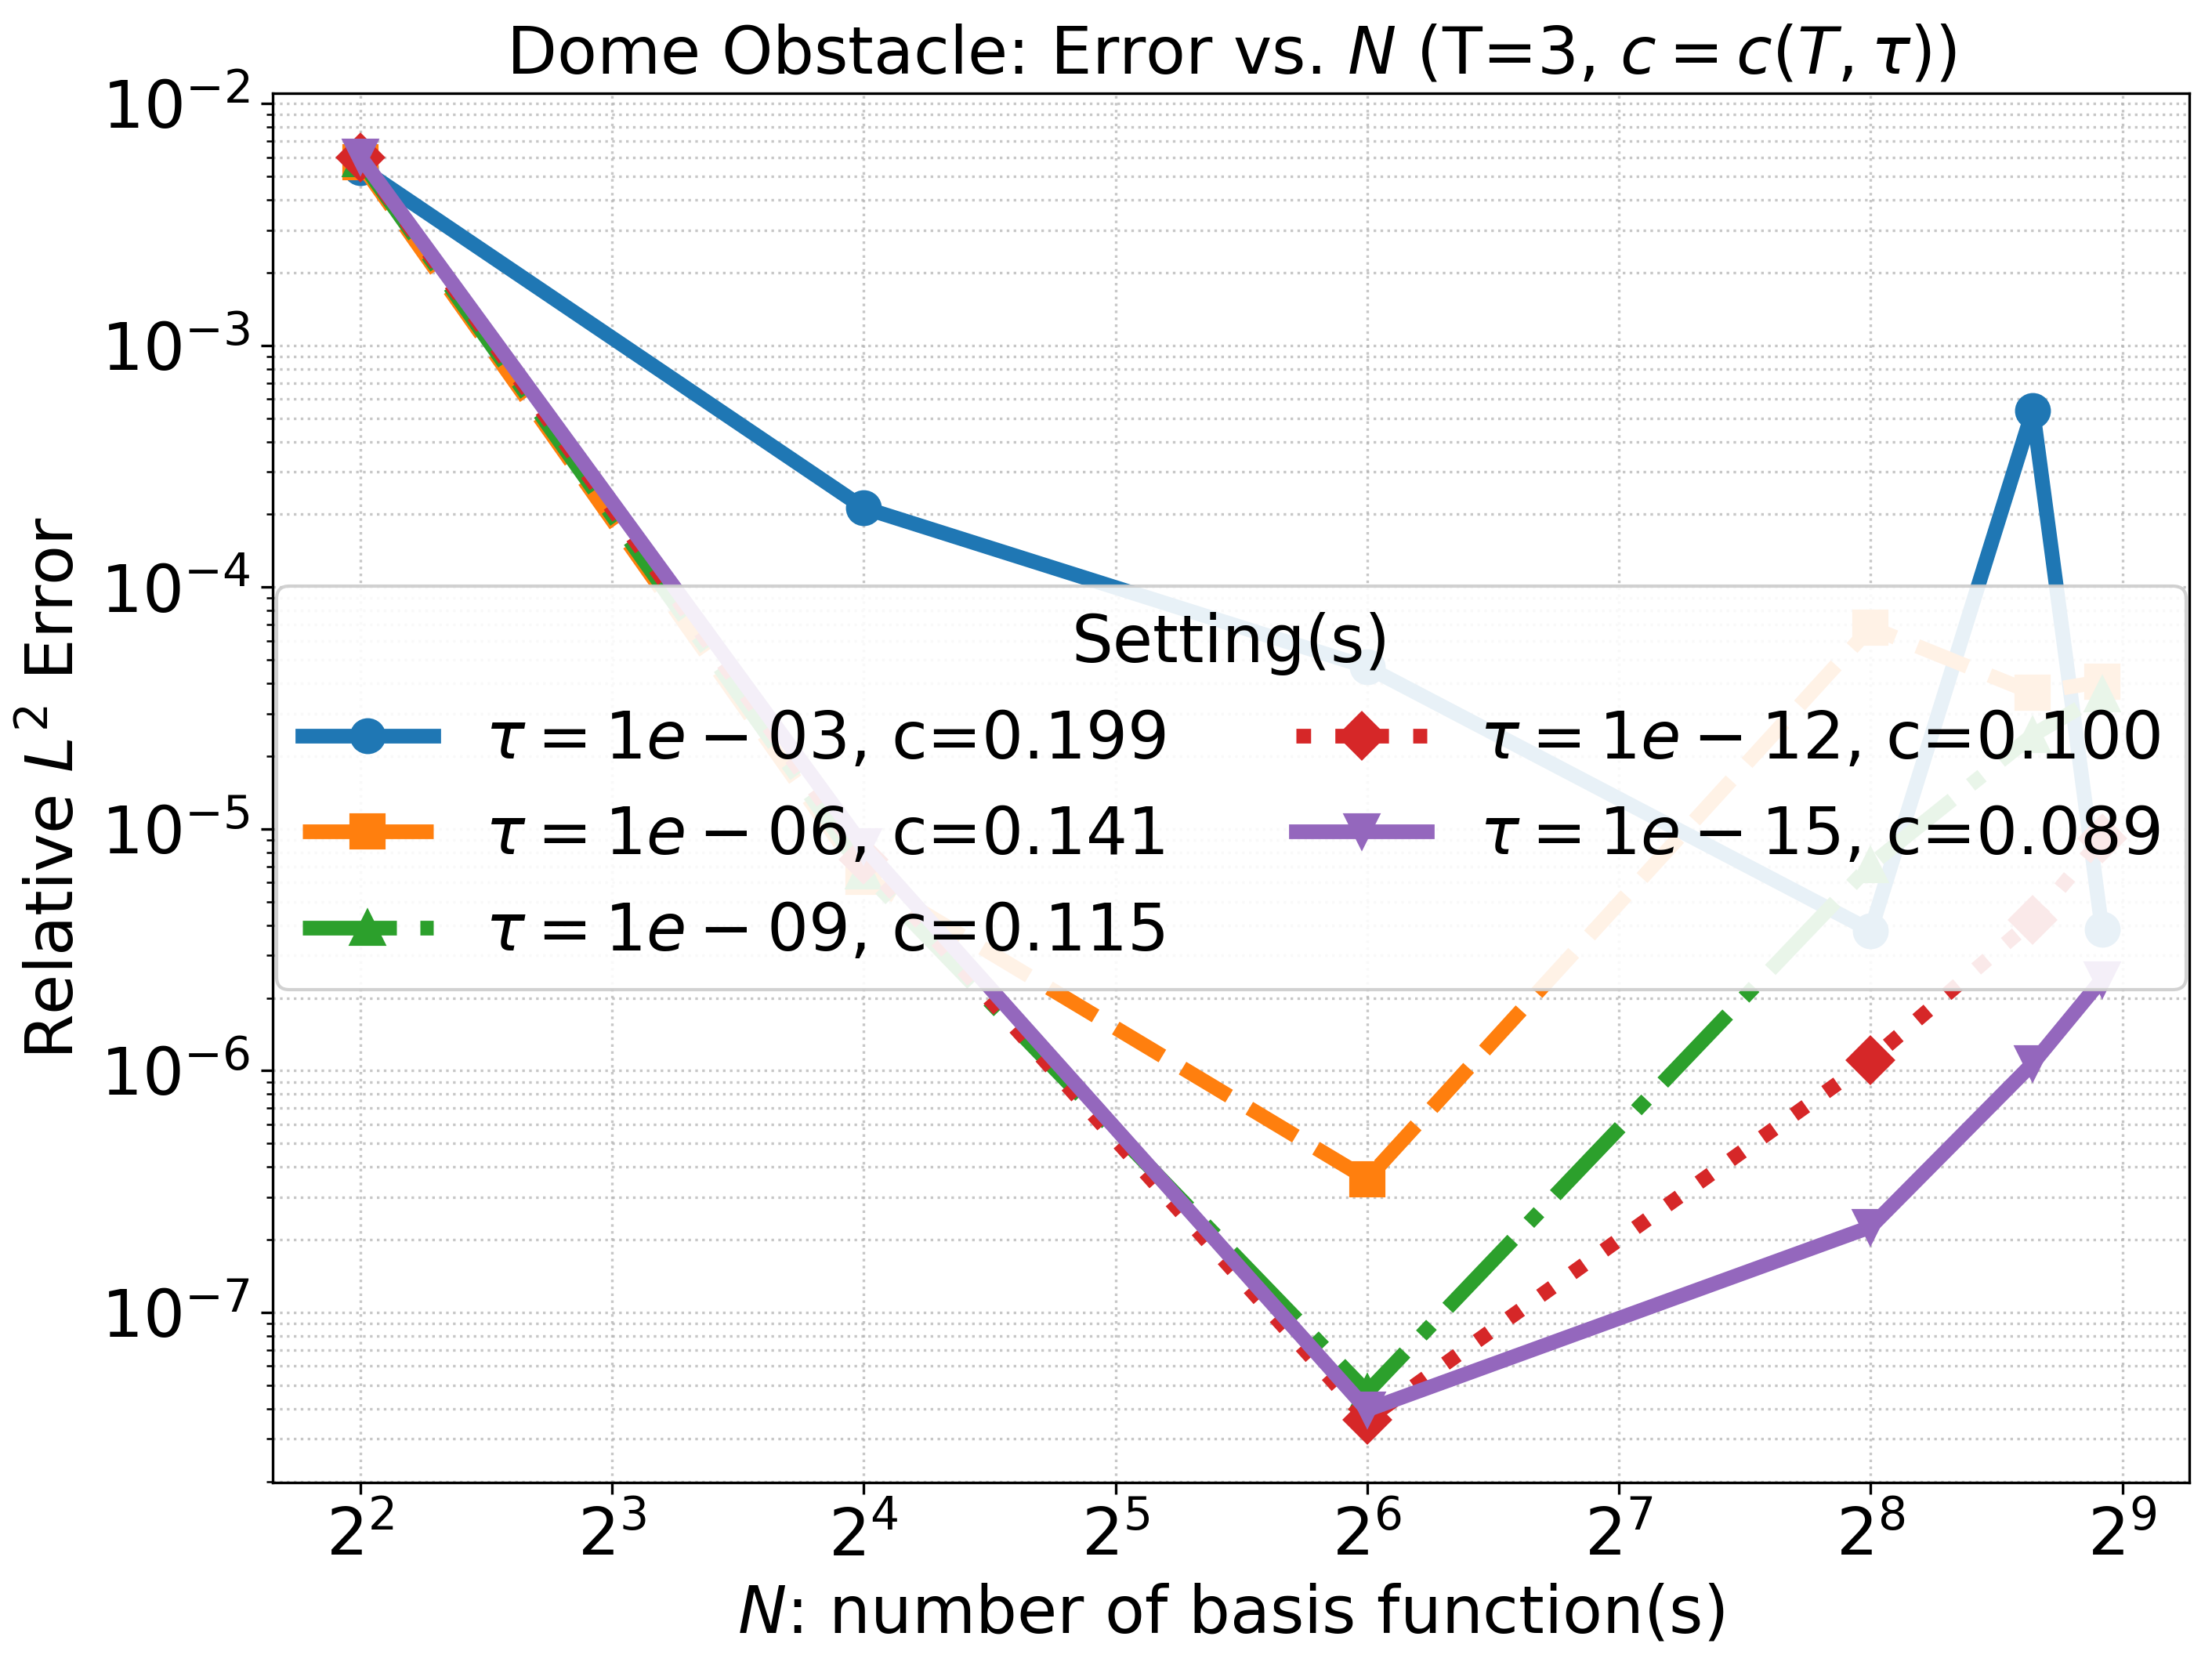

In [9]:
# =======================
# Config (fixed T; sweep tau, c = c(T, tau))
# =======================
N_side_vals = np.array([2, 4, 8, 16, 20, 22], dtype=int)
N_vals      = N_side_vals ** 2

T_fixed   = 3.0
tau_values = np.array([1e-3, 1e-6, 1e-9, 1e-12, 1e-15], dtype=float)

def c_from_T_tau(T: float, tau: float) -> float:
    return float(np.pi / (T * np.sqrt(2.0 * np.log(1.0 + tau**(-2)))))

# compute c_optim per tau (for labels)
c_map = {float(tau): c_from_T_tau(T_fixed, float(tau)) for tau in tau_values}

# Output dirs/files
base_dir = "./Outputs/2D_Obstacle/Psi_Cont"
os.makedirs(base_dir, exist_ok=True)
png_path = os.path.join(base_dir, "fig9_obstacle_2D.png")

legend_ncols = 2

# =======================
# Run experiments (sweep tau; use c=c(T,tau))
# =======================
E = {}        # tau -> relL2 array vs N_side
Times = {}    # tau -> wall time array vs N_side

print("Running rbf_obstacle_solver grid (T fixed; sweep tau with c=c(T,tau)) ...")
rows = [("T", "tau", "N_side", "N", "c_used", "relL2", "time_sec")]

print(f"\nT (fixed) = {T_fixed:g}")
for tau_used in tau_values:
    c_used_val = c_map[float(tau_used)]
    errs, times = [], []
    print(f"\n>>> tau = {tau_used:.0e}, c(T,tau) = {c_used_val:.6f}")

    for N_side in N_side_vals:
        N = int(N_side) ** 2
        zeta_used = 2.0
        M_plot = int(zeta_used * N)

        t0 = time.perf_counter()
        res = rbf_obstacle_solver(
            N=N,
            T_kernel=float(T_fixed),
            c_val=float(c_used_val),    # <-- c from T,tau
            beta_bc=1e6,
            tau_val=float(tau_used),    # <-- sweep tau
            zeta=zeta_used,
            sampling_choice="random",
            seed=123456,
            M_plot=M_plot
        )
        dt = time.perf_counter() - t0

        rel_err = float(res["rel_L2_error"])
        errs.append(rel_err)
        times.append(dt)

        print(f"  N ={N:4d}  relL2={rel_err:.3e}  time={dt:.3f}s  (c={c_used_val:.6f})")
        rows.append((f"{T_fixed:g}", f"{tau_used:.0e}", f"{N_side:d}", f"{N:d}",
                     f"{c_used_val:.6f}", f"{rel_err:.6e}", f"{dt:.6f}"))

    E[float(tau_used)]     = np.asarray(errs, dtype=float)
    Times[float(tau_used)] = np.asarray(times, dtype=float)

# =======================
# Plot Error vs N (log-log)
# =======================
marker_cycle    = cycle(['o', 's', '^', 'D', 'v', 'P', 'X', '*'])
linestyle_cycle = cycle(['-', '--', '-.', ':'])

fig, ax = plt.subplots(figsize=(10, 7.5))
for tau_used in tau_values:
    y = np.asarray(E[float(tau_used)], dtype=float)
    c_val = c_map[float(tau_used)]
    ax.plot(
        N_vals, y,
        marker=next(marker_cycle),
        linestyle=next(linestyle_cycle),
        markersize=10,
        label=rf"$\tau={tau_used:.0e}$, c={c_val:.3f}"
    )

ax.set_xscale('log', base=2)
ax.set_yscale('log')
ax.set_xlabel(r"$N$: number of basis function(s)")
ax.set_ylabel(r"Relative $L^2$ Error")
ax.set_title(rf"Dome Obstacle: Error vs. $N$ (T={T_fixed:g}, $c=c(T,\tau)$)")
ax.grid(True, which='both', linestyle=':')

leg = ax.legend(title="Setting(s)", ncol=legend_ncols, frameon=True, loc='center')
leg.get_frame().set_alpha(0.9)

fig.tight_layout()
fig.savefig(png_path)
# plt.show()

print(f"\nSaved plot to: {png_path}")

# ========== quick best summary ==========
for tau_used in tau_values:
    y = np.asarray(E[float(tau_used)], dtype=float)
    j_best = np.nanargmin(y)
    best_val = y[j_best]
    print(f"tau={tau_used:.0e}: best relL2={best_val:.3e} at N_side={N_side_vals[j_best]} (N={N_side_vals[j_best]**2}), c={c_map[float(tau_used)]:.6f}")

print("\nLegend values (c from T,tau):")
print(f"  T_fixed={T_fixed:g}")
for tau_used in tau_values:
    print(f"  tau={tau_used:.0e}  c={c_map[float(tau_used)]:.6f}")


# T = 6.0

Running rbf_obstacle_solver grid (T fixed; sweep tau with c=c(T,tau)) ...

T (fixed) = 6

>>> tau = 1e-03, c(T,tau) = 0.099609


/tmp/ipykernel_996383/1427297051.py:316: RuntimeWarning: invalid value encountered in scalar divide
  imp_prim = (best_prim - primal_res) / (best_prim if best_prim > tiny else tiny)
/tmp/ipykernel_996383/1427297051.py:317: RuntimeWarning: invalid value encountered in scalar divide
  imp_dual = (best_dual - dual_res)   / (best_dual if best_dual > tiny else tiny)


  N =   4  relL2=5.987e-03  time=2.584s  (c=0.099609)
  N =  16  relL2=5.752e-05  time=2.637s  (c=0.099609)
  N =  64  relL2=3.656e-05  time=0.101s  (c=0.099609)
  N = 256  relL2=3.605e-06  time=35.232s  (c=0.099609)
  N = 400  relL2=1.552e-06  time=100.042s  (c=0.099609)
  N = 484  relL2=1.029e-06  time=134.856s  (c=0.099609)

>>> tau = 1e-06, c(T,tau) = 0.070434
  N =   4  relL2=6.159e-03  time=2.513s  (c=0.070434)
  N =  16  relL2=6.205e-05  time=2.675s  (c=0.070434)
  N =  64  relL2=2.950e-08  time=0.095s  (c=0.070434)
  N = 256  relL2=4.177e-09  time=16.444s  (c=0.070434)
  N = 400  relL2=5.675e-08  time=91.761s  (c=0.070434)
  N = 484  relL2=1.416e-07  time=144.243s  (c=0.070434)

>>> tau = 1e-09, c(T,tau) = 0.057509
  N =   4  relL2=6.222e-03  time=2.498s  (c=0.057509)
  N =  16  relL2=6.866e-05  time=2.667s  (c=0.057509)
  N =  64  relL2=4.210e-08  time=0.081s  (c=0.057509)
  N = 256  relL2=1.148e-10  time=1.692s  (c=0.057509)
  N = 400  relL2=2.643e-09  time=55.542s  (c=0.0575

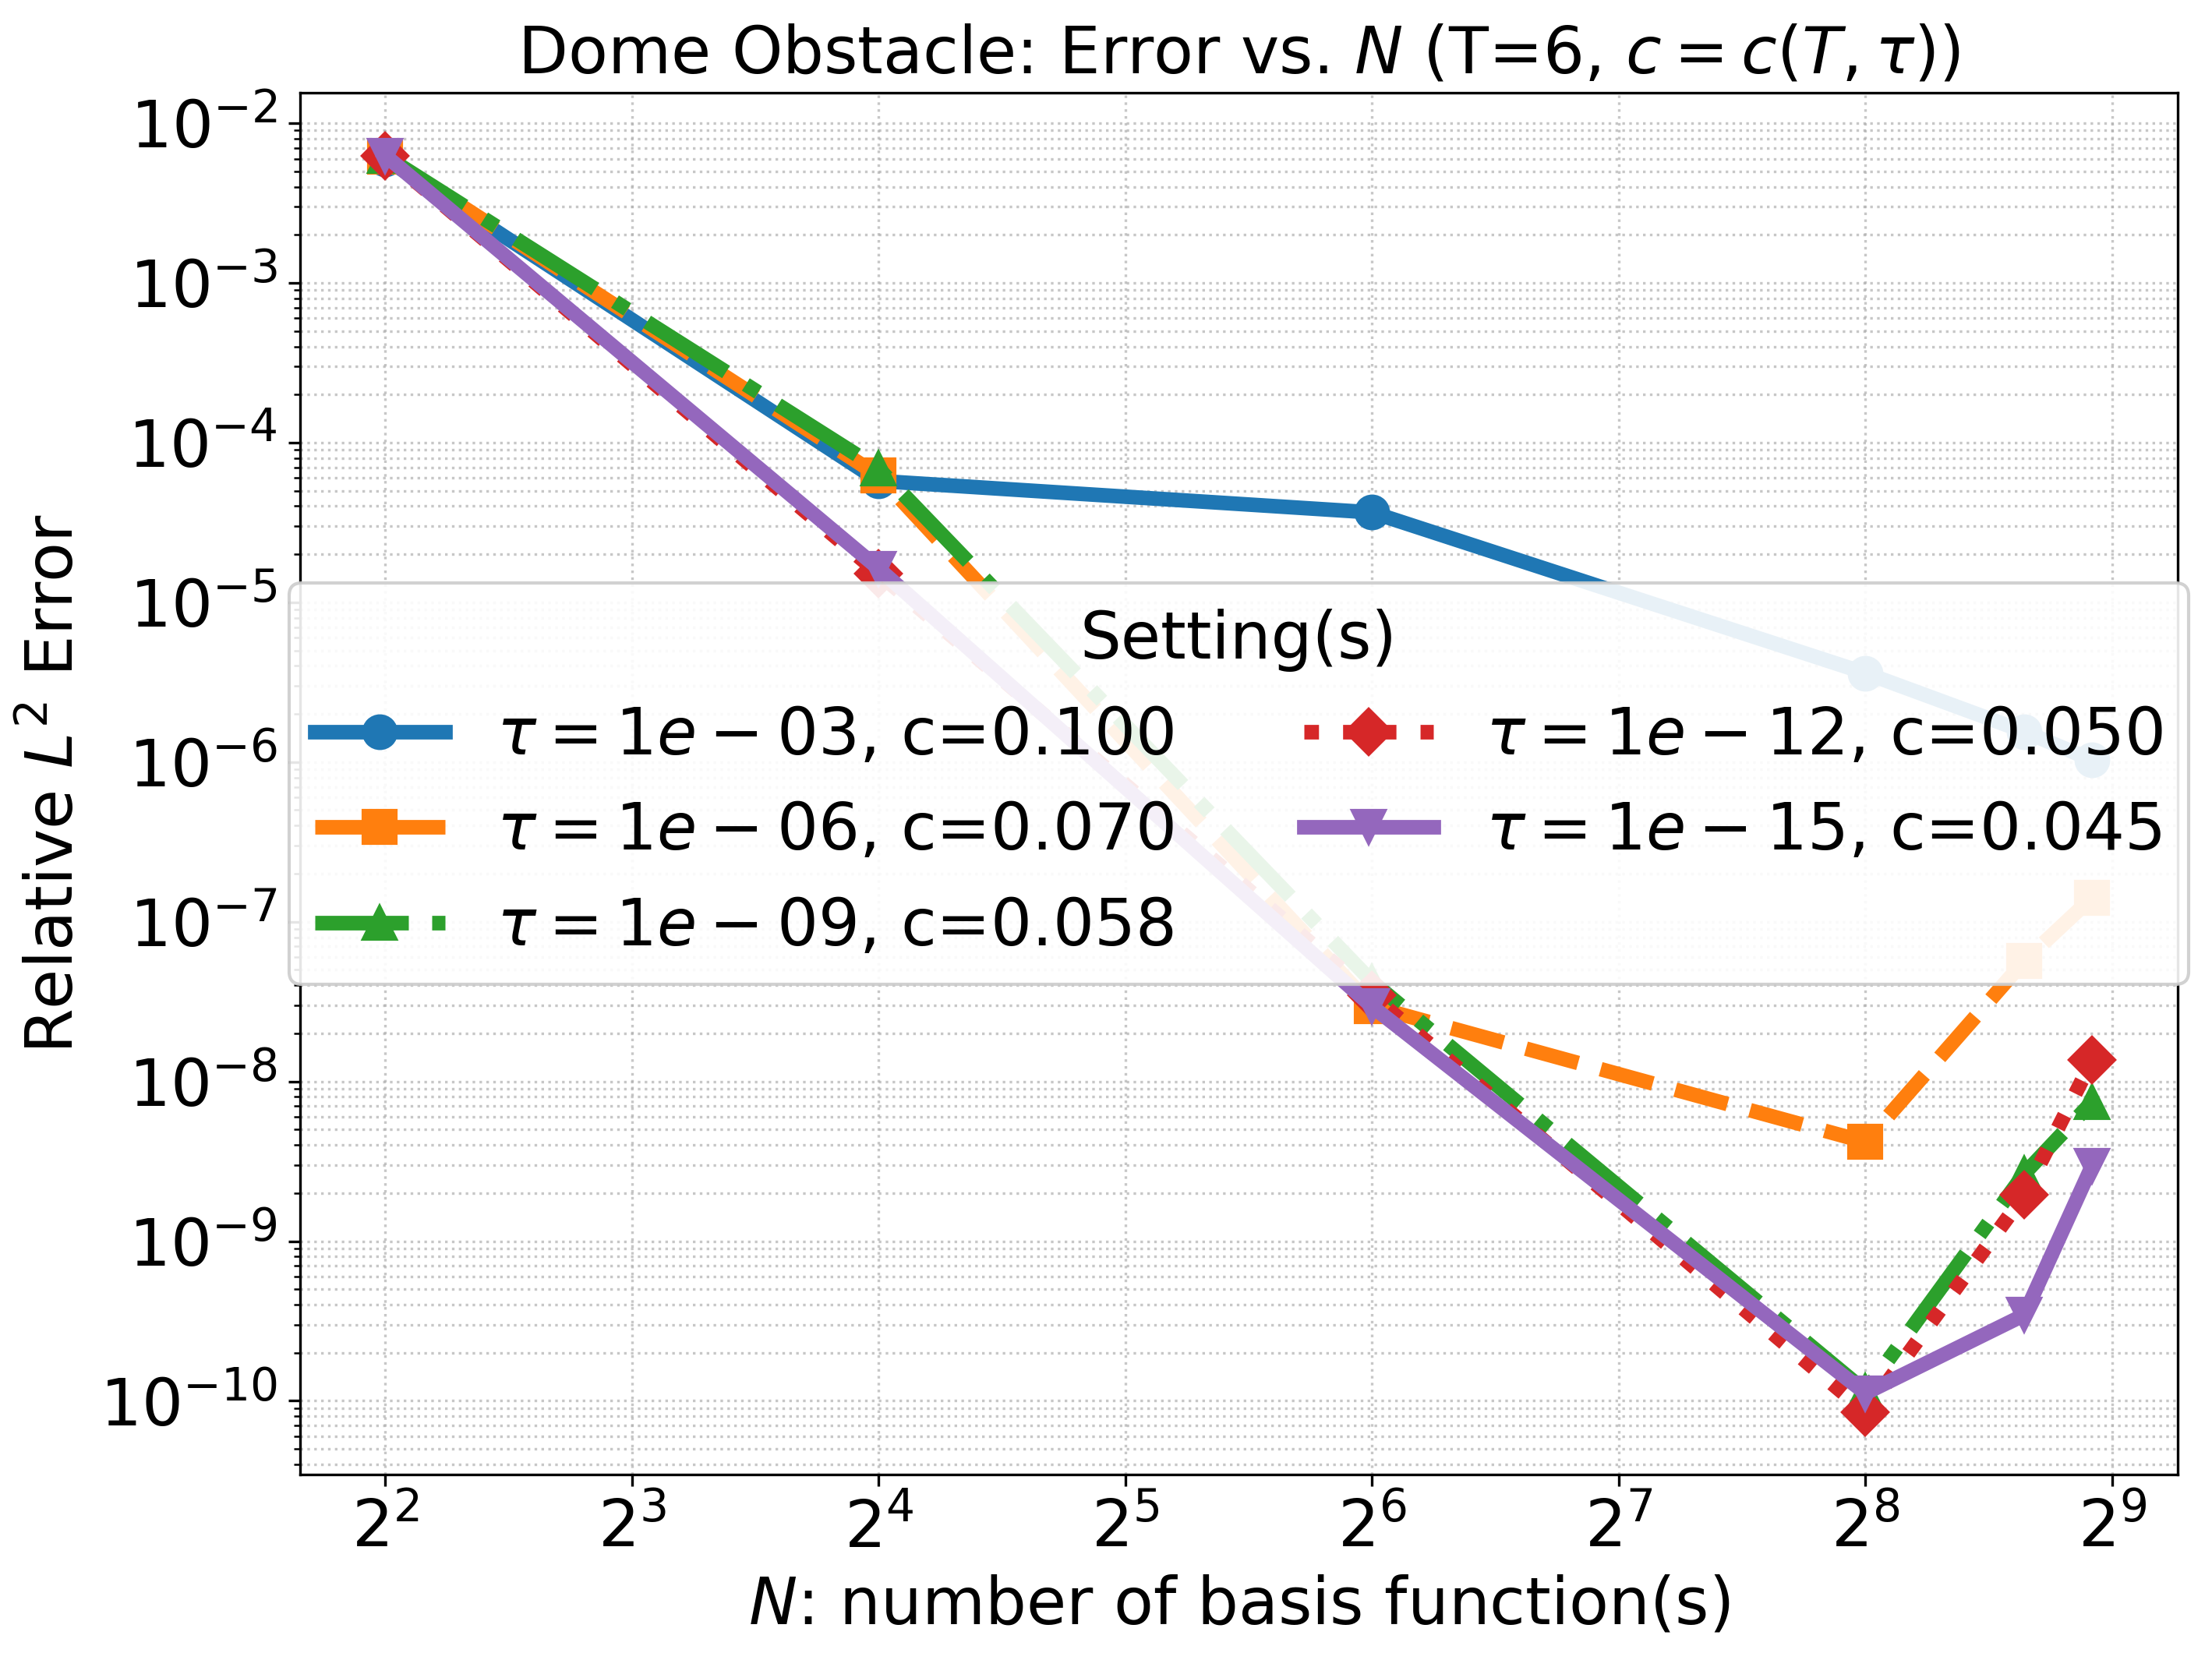

In [10]:
# =======================
# Config (fixed T; sweep tau, c = c(T, tau))
# =======================
N_side_vals = np.array([2, 4, 8, 16, 20, 22], dtype=int)
N_vals      = N_side_vals ** 2

T_fixed   = 6.0
tau_values = np.array([1e-3, 1e-6, 1e-9, 1e-12, 1e-15], dtype=float)

def c_from_T_tau(T: float, tau: float) -> float:
    return float(np.pi / (T * np.sqrt(2.0 * np.log(1.0 + tau**(-2)))))

# compute c_optim per tau (for labels)
c_map = {float(tau): c_from_T_tau(T_fixed, float(tau)) for tau in tau_values}

# Output dirs/files
base_dir = "./Outputs/2D_Obstacle/Psi_Cont"
os.makedirs(base_dir, exist_ok=True)
png_path = os.path.join(base_dir, "fig10_obstacle_2D.png")

legend_ncols = 2

# =======================
# Run experiments (sweep tau; use c=c(T,tau))
# =======================
E = {}        # tau -> relL2 array vs N_side
Times = {}    # tau -> wall time array vs N_side

print("Running rbf_obstacle_solver grid (T fixed; sweep tau with c=c(T,tau)) ...")
rows = [("T", "tau", "N_side", "N", "c_used", "relL2", "time_sec")]

print(f"\nT (fixed) = {T_fixed:g}")
for tau_used in tau_values:
    c_used_val = c_map[float(tau_used)]
    errs, times = [], []
    print(f"\n>>> tau = {tau_used:.0e}, c(T,tau) = {c_used_val:.6f}")

    for N_side in N_side_vals:
        N = int(N_side) ** 2
        zeta_used = 2.0
        M_plot = int(zeta_used * N)

        t0 = time.perf_counter()
        res = rbf_obstacle_solver(
            N=N,
            T_kernel=float(T_fixed),
            c_val=float(c_used_val),    # <-- c from T,tau
            beta_bc=1e6,
            tau_val=float(tau_used),    # <-- sweep tau
            zeta=zeta_used,
            sampling_choice="random",
            seed=123456,
            M_plot=M_plot
        )
        dt = time.perf_counter() - t0

        rel_err = float(res["rel_L2_error"])
        errs.append(rel_err)
        times.append(dt)

        print(f"  N ={N:4d}  relL2={rel_err:.3e}  time={dt:.3f}s  (c={c_used_val:.6f})")
        rows.append((f"{T_fixed:g}", f"{tau_used:.0e}", f"{N_side:d}", f"{N:d}",
                     f"{c_used_val:.6f}", f"{rel_err:.6e}", f"{dt:.6f}"))

    E[float(tau_used)]     = np.asarray(errs, dtype=float)
    Times[float(tau_used)] = np.asarray(times, dtype=float)

# =======================
# Plot Error vs N (log-log)
# =======================
marker_cycle    = cycle(['o', 's', '^', 'D', 'v', 'P', 'X', '*'])
linestyle_cycle = cycle(['-', '--', '-.', ':'])

fig, ax = plt.subplots(figsize=(10, 7.5))
for tau_used in tau_values:
    y = np.asarray(E[float(tau_used)], dtype=float)
    c_val = c_map[float(tau_used)]
    ax.plot(
        N_vals, y,
        marker=next(marker_cycle),
        linestyle=next(linestyle_cycle),
        markersize=10,
        label=rf"$\tau={tau_used:.0e}$, c={c_val:.3f}"
    )

ax.set_xscale('log', base=2)
ax.set_yscale('log')
ax.set_xlabel(r"$N$: number of basis function(s)")
ax.set_ylabel(r"Relative $L^2$ Error")
ax.set_title(rf"Dome Obstacle: Error vs. $N$ (T={T_fixed:g}, $c=c(T,\tau)$)")
ax.grid(True, which='both', linestyle=':')

leg = ax.legend(title="Setting(s)", ncol=legend_ncols, frameon=True, loc='center')
leg.get_frame().set_alpha(0.9)

fig.tight_layout()
fig.savefig(png_path)
# plt.show()

print(f"\nSaved plot to: {png_path}")

# ========== quick best summary ==========
for tau_used in tau_values:
    y = np.asarray(E[float(tau_used)], dtype=float)
    j_best = np.nanargmin(y)
    best_val = y[j_best]
    print(f"tau={tau_used:.0e}: best relL2={best_val:.3e} at N_side={N_side_vals[j_best]} (N={N_side_vals[j_best]**2}), c={c_map[float(tau_used)]:.6f}")

print("\nLegend values (c from T,tau):")
print(f"  T_fixed={T_fixed:g}")
for tau_used in tau_values:
    print(f"  tau={tau_used:.0e}  c={c_map[float(tau_used)]:.6f}")


# T = 8.0

Running rbf_obstacle_solver grid (T fixed; sweep tau with c=c(T,tau)) ...

T (fixed) = 8

>>> tau = 1e-03, c(T,tau) = 0.074707


/tmp/ipykernel_996383/1427297051.py:316: RuntimeWarning: invalid value encountered in scalar divide
  imp_prim = (best_prim - primal_res) / (best_prim if best_prim > tiny else tiny)
/tmp/ipykernel_996383/1427297051.py:317: RuntimeWarning: invalid value encountered in scalar divide
  imp_dual = (best_dual - dual_res)   / (best_dual if best_dual > tiny else tiny)


  N =   4  relL2=6.136e-03  time=2.445s  (c=0.074707)
  N =  16  relL2=6.039e-05  time=2.566s  (c=0.074707)
  N =  64  relL2=2.671e-05  time=3.536s  (c=0.074707)
  N = 256  relL2=3.429e-06  time=16.835s  (c=0.074707)
  N = 400  relL2=1.431e-06  time=94.612s  (c=0.074707)
  N = 484  relL2=1.007e-06  time=145.688s  (c=0.074707)

>>> tau = 1e-06, c(T,tau) = 0.052826
  N =   4  relL2=6.242e-03  time=2.438s  (c=0.052826)
  N =  16  relL2=7.151e-05  time=2.572s  (c=0.052826)
  N =  64  relL2=2.361e-07  time=0.132s  (c=0.052826)
  N = 256  relL2=1.201e-09  time=1.660s  (c=0.052826)
  N = 400  relL2=4.081e-10  time=43.884s  (c=0.052826)
  N = 484  relL2=1.466e-09  time=110.856s  (c=0.052826)

>>> tau = 1e-09, c(T,tau) = 0.043132
  N =   4  relL2=6.279e-03  time=2.467s  (c=0.043132)
  N =  16  relL2=7.785e-05  time=2.637s  (c=0.043132)
  N =  64  relL2=1.243e-08  time=0.076s  (c=0.043132)
  N = 256  relL2=1.212e-10  time=1.681s  (c=0.043132)
  N = 400  relL2=2.099e-10  time=6.353s  (c=0.043132)

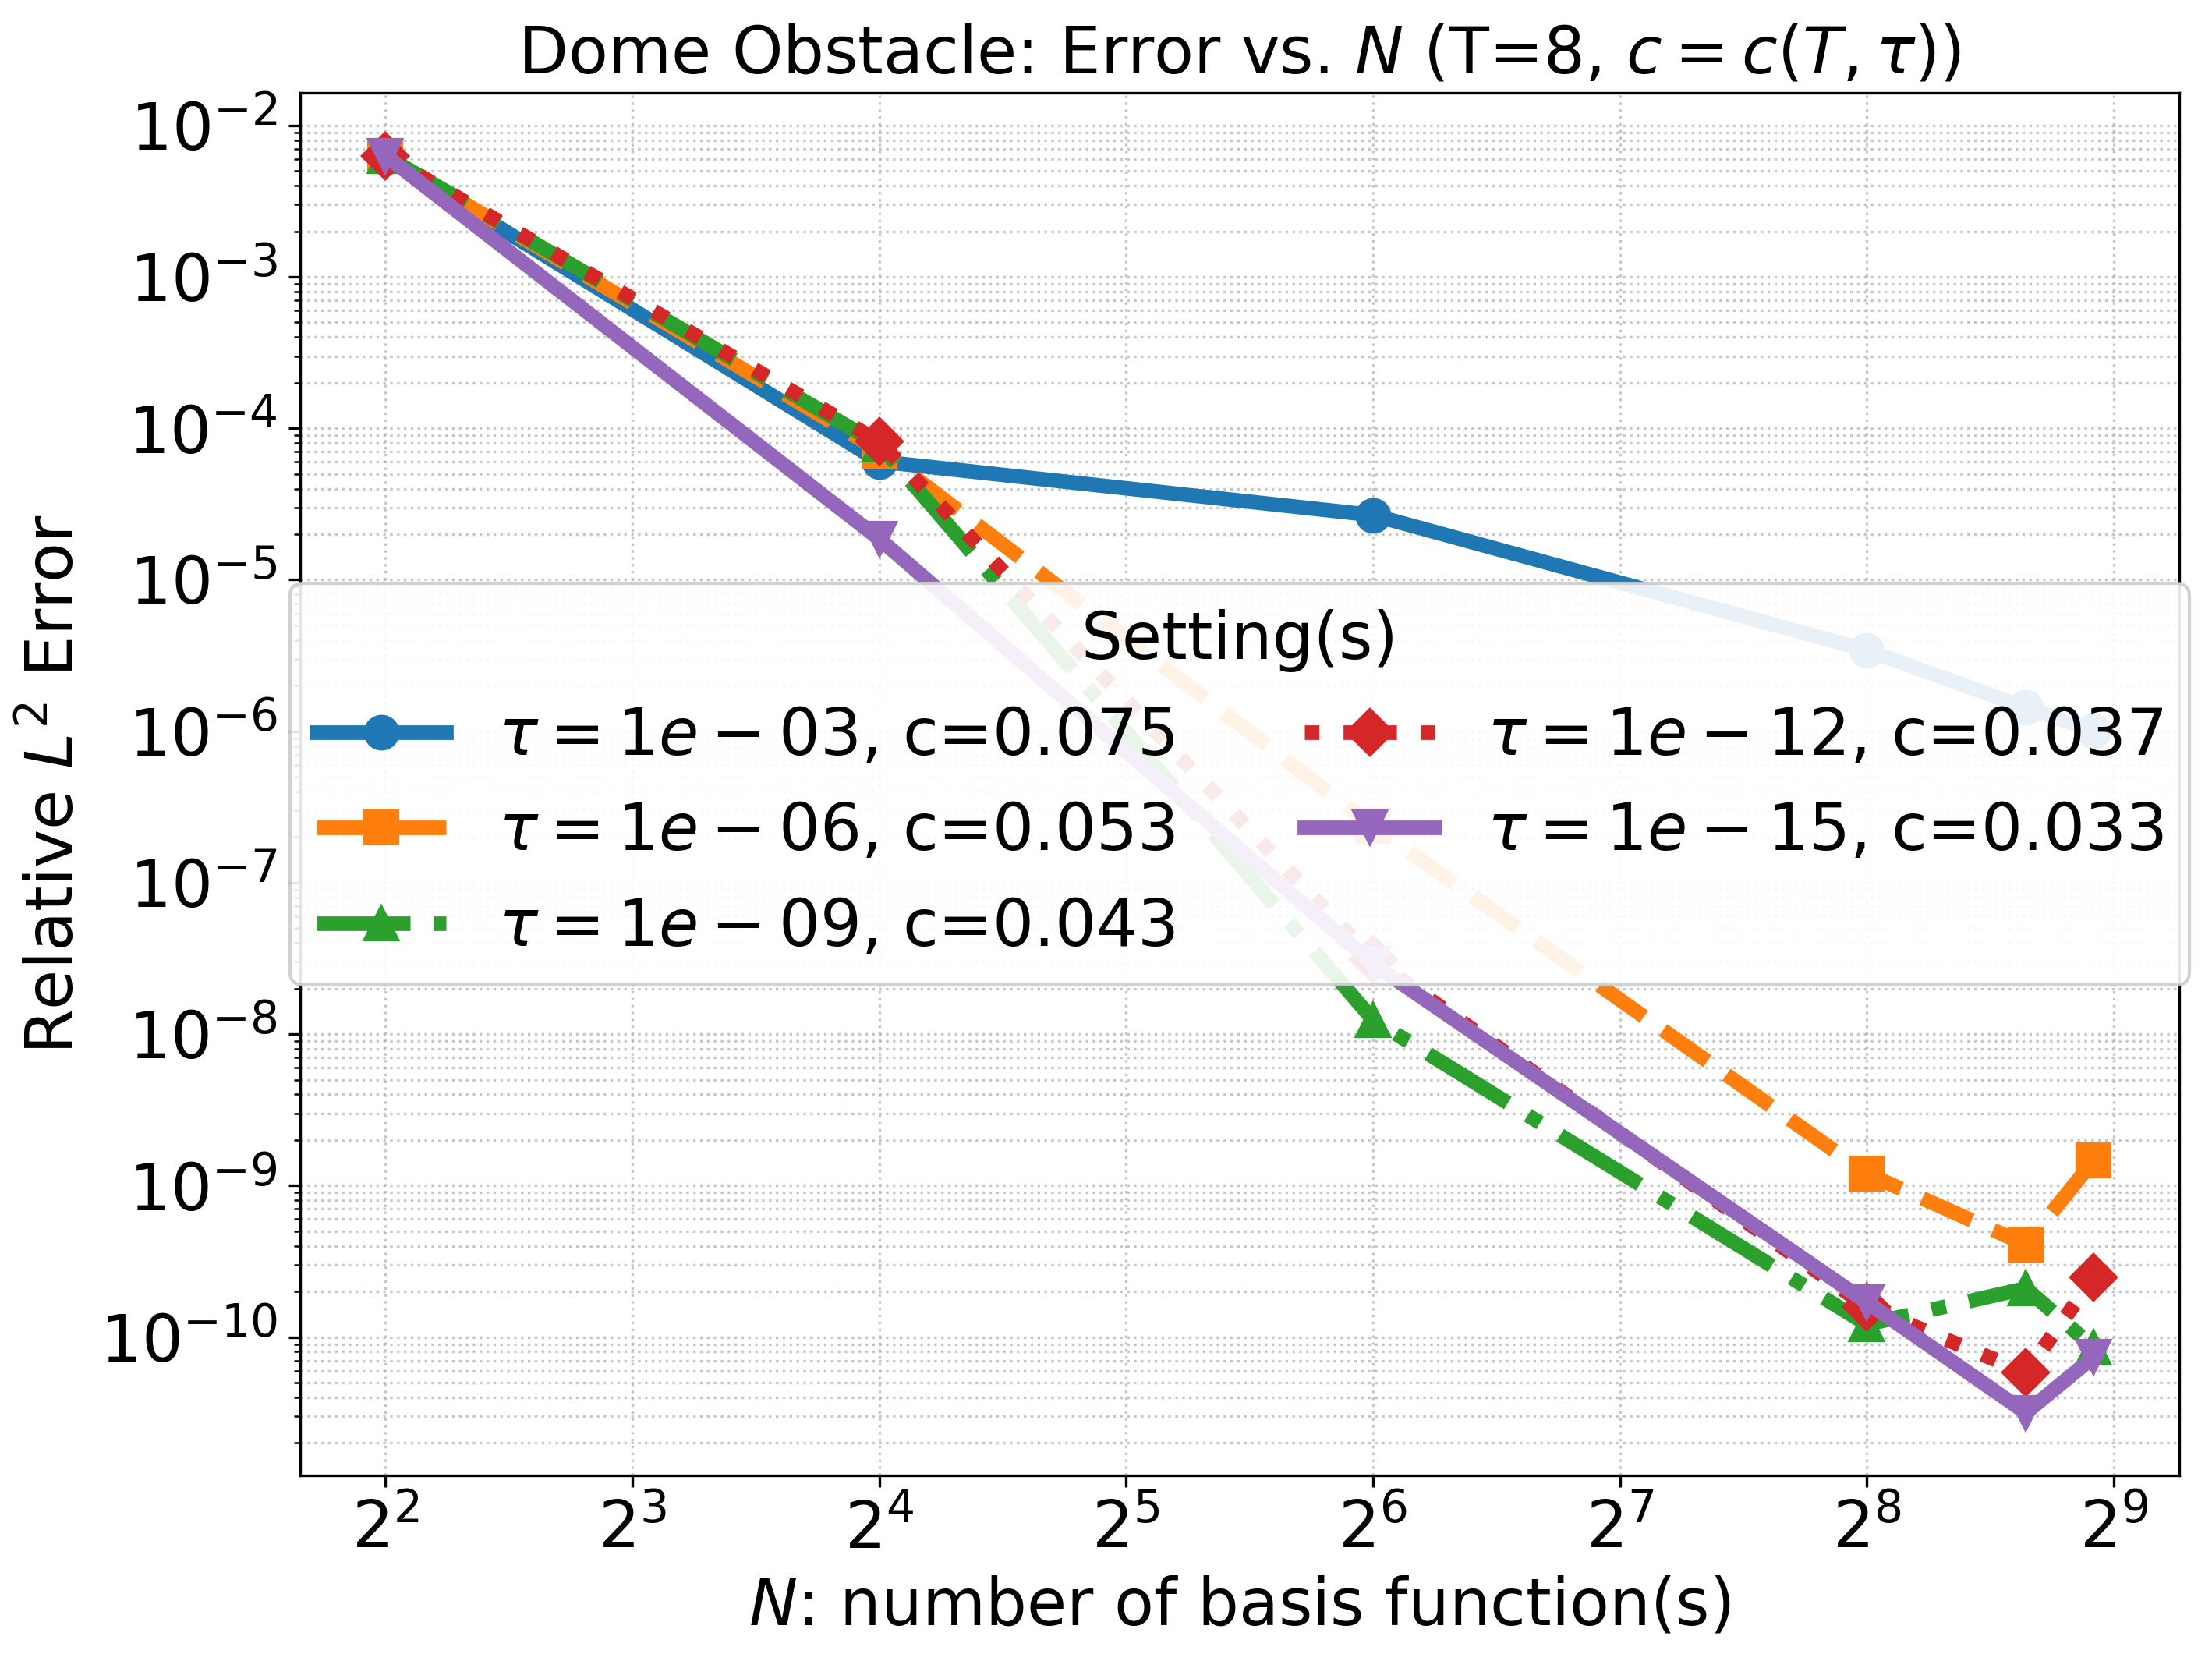

In [11]:
# =======================
# Config (fixed T; sweep tau, c = c(T, tau))
# =======================
N_side_vals = np.array([2, 4, 8, 16, 20, 22], dtype=int)
N_vals      = N_side_vals ** 2

T_fixed   = 8.0
tau_values = np.array([1e-3, 1e-6, 1e-9, 1e-12, 1e-15], dtype=float)

def c_from_T_tau(T: float, tau: float) -> float:
    return float(np.pi / (T * np.sqrt(2.0 * np.log(1.0 + tau**(-2)))))

# compute c_optim per tau (for labels)
c_map = {float(tau): c_from_T_tau(T_fixed, float(tau)) for tau in tau_values}

# Output dirs/files
base_dir = "./Outputs/2D_Obstacle/Psi_Cont"
os.makedirs(base_dir, exist_ok=True)
png_path = os.path.join(base_dir, "fig11_obstacle_2D.png")

legend_ncols = 2

# =======================
# Run experiments (sweep tau; use c=c(T,tau))
# =======================
E = {}        # tau -> relL2 array vs N_side
Times = {}    # tau -> wall time array vs N_side

print("Running rbf_obstacle_solver grid (T fixed; sweep tau with c=c(T,tau)) ...")
rows = [("T", "tau", "N_side", "N", "c_used", "relL2", "time_sec")]

print(f"\nT (fixed) = {T_fixed:g}")
for tau_used in tau_values:
    c_used_val = c_map[float(tau_used)]
    errs, times = [], []
    print(f"\n>>> tau = {tau_used:.0e}, c(T,tau) = {c_used_val:.6f}")

    for N_side in N_side_vals:
        N = int(N_side) ** 2
        zeta_used = 2.0
        M_plot = int(zeta_used * N)

        t0 = time.perf_counter()
        res = rbf_obstacle_solver(
            N=N,
            T_kernel=float(T_fixed),
            c_val=float(c_used_val),    # <-- c from T,tau
            beta_bc=1e6,
            tau_val=float(tau_used),    # <-- sweep tau
            zeta=zeta_used,
            sampling_choice="random",
            seed=123456,
            M_plot=M_plot
        )
        dt = time.perf_counter() - t0

        rel_err = float(res["rel_L2_error"])
        errs.append(rel_err)
        times.append(dt)

        print(f"  N ={N:4d}  relL2={rel_err:.3e}  time={dt:.3f}s  (c={c_used_val:.6f})")
        rows.append((f"{T_fixed:g}", f"{tau_used:.0e}", f"{N_side:d}", f"{N:d}",
                     f"{c_used_val:.6f}", f"{rel_err:.6e}", f"{dt:.6f}"))

    E[float(tau_used)]     = np.asarray(errs, dtype=float)
    Times[float(tau_used)] = np.asarray(times, dtype=float)

# =======================
# Plot Error vs N (log-log)
# =======================
marker_cycle    = cycle(['o', 's', '^', 'D', 'v', 'P', 'X', '*'])
linestyle_cycle = cycle(['-', '--', '-.', ':'])

fig, ax = plt.subplots(figsize=(10, 7.5))
for tau_used in tau_values:
    y = np.asarray(E[float(tau_used)], dtype=float)
    c_val = c_map[float(tau_used)]
    ax.plot(
        N_vals, y,
        marker=next(marker_cycle),
        linestyle=next(linestyle_cycle),
        markersize=10,
        label=rf"$\tau={tau_used:.0e}$, c={c_val:.3f}"
    )

ax.set_xscale('log', base=2)
ax.set_yscale('log')
ax.set_xlabel(r"$N$: number of basis function(s)")
ax.set_ylabel(r"Relative $L^2$ Error")
ax.set_title(rf"Dome Obstacle: Error vs. $N$ (T={T_fixed:g}, $c=c(T,\tau)$)")
ax.grid(True, which='both', linestyle=':')

leg = ax.legend(title="Setting(s)", ncol=legend_ncols, frameon=True, loc='center')
leg.get_frame().set_alpha(0.9)

fig.tight_layout()
fig.savefig(png_path)
# plt.show()

print(f"\nSaved plot to: {png_path}")

# ========== quick best summary ==========
for tau_used in tau_values:
    y = np.asarray(E[float(tau_used)], dtype=float)
    j_best = np.nanargmin(y)
    best_val = y[j_best]
    print(f"tau={tau_used:.0e}: best relL2={best_val:.3e} at N_side={N_side_vals[j_best]} (N={N_side_vals[j_best]**2}), c={c_map[float(tau_used)]:.6f}")

print("\nLegend values (c from T,tau):")
print(f"  T_fixed={T_fixed:g}")
for tau_used in tau_values:
    print(f"  tau={tau_used:.0e}  c={c_map[float(tau_used)]:.6f}")


# T = 10.0

Running rbf_obstacle_solver grid (T fixed; sweep tau with c=c(T,tau)) ...

T (fixed) = 10

>>> tau = 1e-03, c(T,tau) = 0.059766


/tmp/ipykernel_996383/1427297051.py:316: RuntimeWarning: invalid value encountered in scalar divide
  imp_prim = (best_prim - primal_res) / (best_prim if best_prim > tiny else tiny)
/tmp/ipykernel_996383/1427297051.py:317: RuntimeWarning: invalid value encountered in scalar divide
  imp_dual = (best_dual - dual_res)   / (best_dual if best_dual > tiny else tiny)


  N =   4  relL2=6.211e-03  time=2.480s  (c=0.059766)
  N =  16  relL2=2.329e-04  time=2.586s  (c=0.059766)
  N =  64  relL2=1.733e-05  time=3.630s  (c=0.059766)
  N = 256  relL2=3.289e-06  time=16.000s  (c=0.059766)
  N = 400  relL2=1.412e-06  time=63.052s  (c=0.059766)
  N = 484  relL2=9.928e-07  time=131.524s  (c=0.059766)

>>> tau = 1e-06, c(T,tau) = 0.042261
  N =   4  relL2=6.282e-03  time=2.535s  (c=0.042261)
  N =  16  relL2=7.843e-05  time=2.582s  (c=0.042261)
  N =  64  relL2=2.419e-07  time=0.092s  (c=0.042261)
  N = 256  relL2=1.097e-09  time=1.719s  (c=0.042261)
  N = 400  relL2=1.778e-10  time=5.842s  (c=0.042261)
  N = 484  relL2=6.329e-11  time=11.359s  (c=0.042261)

>>> tau = 1e-09, c(T,tau) = 0.034506
  N =   4  relL2=6.306e-03  time=2.460s  (c=0.034506)
  N =  16  relL2=8.357e-05  time=2.582s  (c=0.034506)
  N =  64  relL2=1.014e-08  time=0.054s  (c=0.034506)
  N = 256  relL2=1.689e-10  time=1.701s  (c=0.034506)
  N = 400  relL2=3.432e-11  time=6.152s  (c=0.034506)
 

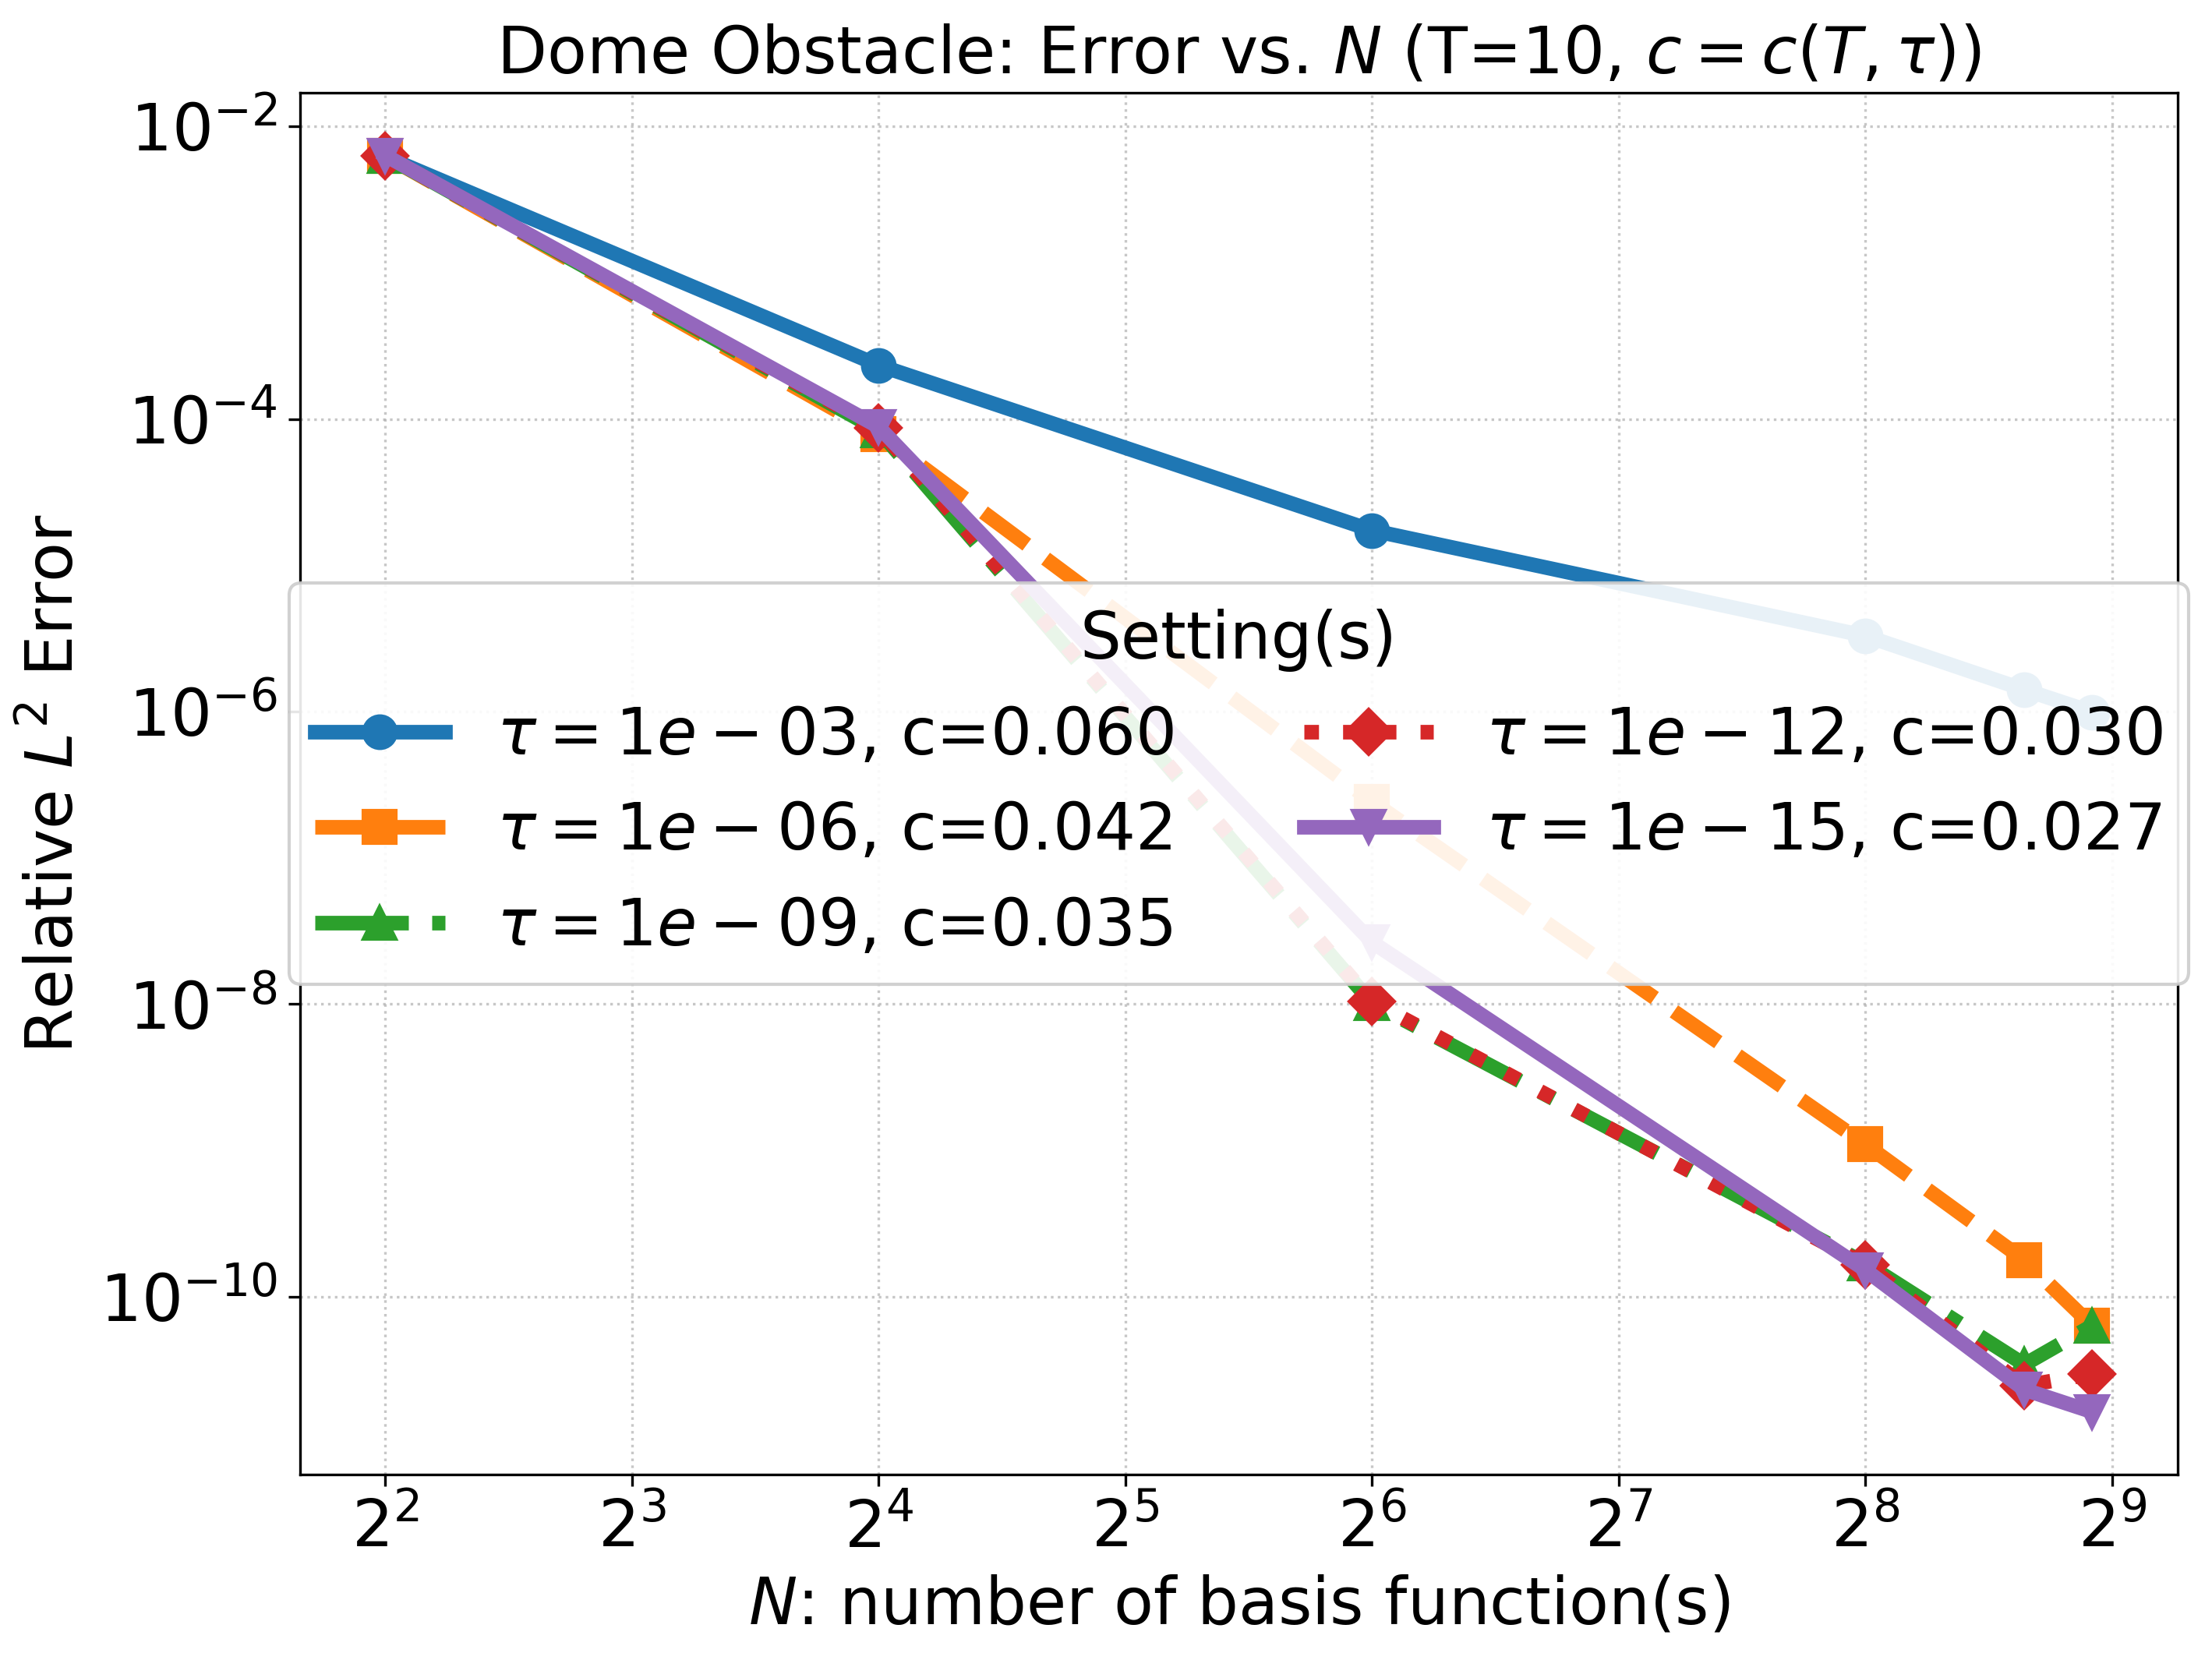

In [12]:
# =======================
# Config (fixed T; sweep tau, c = c(T, tau))
# =======================
N_side_vals = np.array([2, 4, 8, 16, 20, 22], dtype=int)
N_vals      = N_side_vals ** 2

T_fixed   = 10.0
tau_values = np.array([1e-3, 1e-6, 1e-9, 1e-12, 1e-15], dtype=float)

def c_from_T_tau(T: float, tau: float) -> float:
    return float(np.pi / (T * np.sqrt(2.0 * np.log(1.0 + tau**(-2)))))

# compute c_optim per tau (for labels)
c_map = {float(tau): c_from_T_tau(T_fixed, float(tau)) for tau in tau_values}

# Output dirs/files
base_dir = "./Outputs/2D_Obstacle/Psi_Cont"
os.makedirs(base_dir, exist_ok=True)
png_path = os.path.join(base_dir, "fig12_obstacle_2D.png")

legend_ncols = 2

# =======================
# Run experiments (sweep tau; use c=c(T,tau))
# =======================
E = {}        # tau -> relL2 array vs N_side
Times = {}    # tau -> wall time array vs N_side

print("Running rbf_obstacle_solver grid (T fixed; sweep tau with c=c(T,tau)) ...")
rows = [("T", "tau", "N_side", "N", "c_used", "relL2", "time_sec")]

print(f"\nT (fixed) = {T_fixed:g}")
for tau_used in tau_values:
    c_used_val = c_map[float(tau_used)]
    errs, times = [], []
    print(f"\n>>> tau = {tau_used:.0e}, c(T,tau) = {c_used_val:.6f}")

    for N_side in N_side_vals:
        N = int(N_side) ** 2
        zeta_used = 2.0
        M_plot = int(zeta_used * N)

        t0 = time.perf_counter()
        res = rbf_obstacle_solver(
            N=N,
            T_kernel=float(T_fixed),
            c_val=float(c_used_val),    # <-- c from T,tau
            beta_bc=1e6,
            tau_val=float(tau_used),    # <-- sweep tau
            zeta=zeta_used,
            sampling_choice="random",
            seed=123456,
            M_plot=M_plot
        )
        dt = time.perf_counter() - t0

        rel_err = float(res["rel_L2_error"])
        errs.append(rel_err)
        times.append(dt)

        print(f"  N ={N:4d}  relL2={rel_err:.3e}  time={dt:.3f}s  (c={c_used_val:.6f})")
        rows.append((f"{T_fixed:g}", f"{tau_used:.0e}", f"{N_side:d}", f"{N:d}",
                     f"{c_used_val:.6f}", f"{rel_err:.6e}", f"{dt:.6f}"))

    E[float(tau_used)]     = np.asarray(errs, dtype=float)
    Times[float(tau_used)] = np.asarray(times, dtype=float)

# =======================
# Plot Error vs N (log-log)
# =======================
marker_cycle    = cycle(['o', 's', '^', 'D', 'v', 'P', 'X', '*'])
linestyle_cycle = cycle(['-', '--', '-.', ':'])

fig, ax = plt.subplots(figsize=(10, 7.5))
for tau_used in tau_values:
    y = np.asarray(E[float(tau_used)], dtype=float)
    c_val = c_map[float(tau_used)]
    ax.plot(
        N_vals, y,
        marker=next(marker_cycle),
        linestyle=next(linestyle_cycle),
        markersize=10,
        label=rf"$\tau={tau_used:.0e}$, c={c_val:.3f}"
    )

ax.set_xscale('log', base=2)
ax.set_yscale('log')
ax.set_xlabel(r"$N$: number of basis function(s)")
ax.set_ylabel(r"Relative $L^2$ Error")
ax.set_title(rf"Dome Obstacle: Error vs. $N$ (T={T_fixed:g}, $c=c(T,\tau)$)")
ax.grid(True, which='both', linestyle=':')

leg = ax.legend(title="Setting(s)", ncol=legend_ncols, frameon=True, loc='center')
leg.get_frame().set_alpha(0.9)

fig.tight_layout()
fig.savefig(png_path)
# plt.show()

print(f"\nSaved plot to: {png_path}")

# ========== quick best summary ==========
for tau_used in tau_values:
    y = np.asarray(E[float(tau_used)], dtype=float)
    j_best = np.nanargmin(y)
    best_val = y[j_best]
    print(f"tau={tau_used:.0e}: best relL2={best_val:.3e} at N_side={N_side_vals[j_best]} (N={N_side_vals[j_best]**2}), c={c_map[float(tau_used)]:.6f}")

print("\nLegend values (c from T,tau):")
print(f"  T_fixed={T_fixed:g}")
for tau_used in tau_values:
    print(f"  tau={tau_used:.0e}  c={c_map[float(tau_used)]:.6f}")
